# Table of Contents

- [0. Setup & Data Loading](#0-setup--data-loading)
- [1. Exploratory Data Analysis (EDA)](#1-exploratory-data-analysis-eda)
  - [1.1 General Overview](#11-general-overview)
  - [1.2 Target Variable: AdoptionSpeed](#12-target-variable-adoptionspeed)
  - [1.3 Pet Characteristics](#13-pet-characteristics)
  - [1.4 Health & Care Status](#14-health--care-status)
  - [1.5 Listing Quality & Marketing](#15-listing-quality--marketing)
  - [1.6 Geography](#16-geography)
  - [1.7 Correlation Summary](#17-correlation-summary)
  - [1.8 Sentiment Analysis (JSON)](#18-sentiment-analysis-json)
  - [1.9 Key Takeaways](#19-key-takeaways)
- [2. Predictive Modeling](#2-predictive-modeling)
  - [2.1 Feature Engineering](#21-feature-engineering)
  - [2.2 Train/Test Split](#22-traintest-split)
  - [2.3 Preprocessing & Scaling](#23-preprocessing--scaling)
  - [2.4 XGBoost Model](#24-xgboost-model)
- [3. Model Evaluation & Selection](#3-model-evaluation--selection)
  - [3.1 Metric Choice](#31-metric-choice)
  - [3.2 Model Comparison](#32-model-comparison)
    - [3.2.1 Metrics Table](#321-metrics-table)
    - [3.2.2 Bar Plot](#322-bar-plot)
    - [3.2.3 Confusion Matrices](#323-confusion-matrices)
    - [3.2.4 ROC Curve](#324-roc-curve)
    - [3.2.5 Precision–Recall Curve](#325-precisionrecall-curve)
  - [3.3 Feature Importance](#33-feature-importance)
  - [3.4 JSON Sentiment Feature Impact](#34-json-sentiment-feature-impact)
  - [3.5 Performance Test: Sentiment Approaches](#35-performance-test-sentiment-approaches)
- [4. Save Model Pipeline](#4-save-model-pipeline)
  - [4.1 Select Final Pipeline](#41-select-final-pipeline)
  - [4.2 Save Pipeline to Pickle](#42-save-pipeline-to-pickle)
- [5. Drivers of Escalation & Recommendation](#5-drivers-of-escalation--recommendation)
  - [5.1 Key Drivers](#51-key-drivers)
  - [5.2 Strategic Action](#52-strategic-action)

---

# 0. Setup & Data Loading

In [1]:
# We start by loading the project configuration and data
import os, sys, importlib
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# --- Robust project-root setup (no hard-coded C:\... needed) ---
HERE = Path.cwd()
PROJECT_ROOT = next(
    (p for p in [HERE, *HERE.parents] if (p / "src").is_dir() and (p / "data").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise RuntimeError(f"Could not locate project root from {HERE}. Expected 'src/' and 'data/' folders.")

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# --- Force-reload config so notebook doesn't use an older cached version ---
import src.config as config_module
importlib.reload(config_module)
from src.config import Config

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)

cfg = Config()

# --- Debug + safe path fallback if config is stale ---
print("Config loaded from:", config_module.__file__)
print("PROJECT_ROOT:", PROJECT_ROOT)

def _resolve_or_fallback(p: Path, fallback: Path, label: str) -> Path:
    p = Path(p)
    if p.exists():
        return p
    if fallback.exists():
        print(f"[WARN] {label} not found at {p} -> using {fallback}")
        return fallback
    raise FileNotFoundError(f"{label} not found. Tried:\n- {p}\n- {fallback}")

train_csv = _resolve_or_fallback(
    cfg.TRAIN_CSV,
    PROJECT_ROOT / "data" / "train" / "train.csv",
    "TRAIN_CSV",
)
breed_csv = _resolve_or_fallback(
    cfg.BREED_LABELS,
    PROJECT_ROOT / "data" / "breed_labels.csv",
    "BREED_LABELS",
)
color_csv = _resolve_or_fallback(
    cfg.COLOR_LABELS,
    PROJECT_ROOT / "data" / "color_labels.csv",
    "COLOR_LABELS",
)
state_csv = _resolve_or_fallback(
    cfg.STATE_LABELS,
    PROJECT_ROOT / "data" / "state_labels.csv",
    "STATE_LABELS",
)

df = pd.read_csv(train_csv)
breed_labels = pd.read_csv(breed_csv)
color_labels = pd.read_csv(color_csv)
state_labels = pd.read_csv(state_csv)

# --- Label mappings ---
speed_labels = {0: "Same day", 1: "1-7d", 2: "8-30d", 3: "31-90d", 4: "No adoption"}
color_map = color_labels.set_index("ColorID")["ColorName"].to_dict()
state_map = state_labels.set_index("StateID")["StateName"].to_dict()

df["AdoptionSpeed_label"] = df["AdoptionSpeed"].map(speed_labels)
df["Type_label"] = df["Type"].map({1: "Dog", 2: "Cat"})
df["Gender_label"] = df["Gender"].map({1: "Male", 2: "Female", 3: "Mixed"})
df["MaturitySize_label"] = df["MaturitySize"].map({0: "N/A", 1: "Small", 2: "Medium", 3: "Large", 4: "Extra Large"})
df["FurLength_label"] = df["FurLength"].map({0: "N/A", 1: "Short", 2: "Medium", 3: "Long"})
df["Vaccinated_label"] = df["Vaccinated"].map({1: "Yes", 2: "No", 3: "Not Sure"})
df["Dewormed_label"] = df["Dewormed"].map({1: "Yes", 2: "No", 3: "Not Sure"})
df["Sterilized_label"] = df["Sterilized"].map({1: "Yes", 2: "No", 3: "Not Sure"})
df["Health_label"] = df["Health"].map({1: "Healthy", 2: "Minor Injury", 3: "Serious Injury"})
df["Color1_label"] = df["Color1"].map(color_map)
df["State_label"] = df["State"].map(state_map)

# --- Derived features ---
df["age_bin"] = pd.cut(df["Age"], bins=[-1, 1, 3, 12, 24, 300], labels=["<1mo", "1-3mo", "3-12mo", "1-2yr", "2yr+"])
df["desc_len"] = df["Description"].fillna("").str.len()
df["desc_word_count"] = df["Description"].fillna("").str.split().str.len()
df["has_name"] = df["Name"].notna().map({True: "Has Name", False: "No Name"})
df["has_photo"] = (df["PhotoAmt"] > 0).map({True: "Yes", False: "No"})
df["has_video"] = (df["VideoAmt"] > 0).map({True: "Yes", False: "No"})
df["is_free"] = (df["Fee"] == 0).map({True: "Free", False: "Paid"})
df["photo_bin"] = pd.cut(df["PhotoAmt"], bins=[-1, 0, 2, 5, 10, 100], labels=["0", "1-2", "3-5", "6-10", "10+"])
df["desc_bin"] = pd.cut(df["desc_word_count"], bins=[-1, 0, 25, 75, 150, 1000], labels=["None", "Short", "Medium", "Long", "Very Long"])

print(f"Dataset: {df.shape[0]:,} pets, {df.shape[1]} columns")
print(f"Label files: {len(breed_labels)} breeds | {len(color_labels)} colors | {len(state_labels)} states")
df.head()

Config loaded from: /Users/lenny/AdoptSense-Pet-Adoption-Prediction/src/config.py
PROJECT_ROOT: /Users/lenny/AdoptSense-Pet-Adoption-Prediction
Dataset: 14,993 pets, 44 columns
Label files: 307 breeds | 7 colors | 15 states


,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,...,State_label,age_bin,desc_len,desc_word_count,has_name,has_photo,has_video,is_free,photo_bin,desc_bin
0,2,Nibble,3,299,0,1,1,7,0,1,...,Selangor,1-3mo,359,69,Has Name,Yes,No,Paid,1-2,Medium
1,2,No Name Yet,1,265,0,1,1,2,0,2,...,Kuala Lumpur,<1mo,118,23,Has Name,Yes,No,Free,1-2,Short
2,1,Brisco,1,307,0,1,2,7,0,2,...,Selangor,<1mo,393,69,Has Name,Yes,No,Free,6-10,Medium
3,1,Miko,4,307,0,2,1,2,0,2,...,Kuala Lumpur,3-12mo,146,25,Has Name,Yes,No,Paid,6-10,Short
4,1,Hunter,1,307,0,1,1,0,0,2,...,Selangor,<1mo,390,81,Has Name,Yes,No,Free,3-5,Long


In [2]:
# We load Google NLP sentiment features and merge them into df on PetID
from src.features_sentiment import SentimentFeatures, SENTIMENT_FEATURE_COLS

train_sentiment_dir = _resolve_or_fallback(
    cfg.TRAIN_SENTIMENT_DIR,
    PROJECT_ROOT / "src" / "data" / "train_sentiment",
    "TRAIN_SENTIMENT_DIR",
)

sf = SentimentFeatures(train_sentiment_dir)
_coverage = sf.coverage(df["PetID"])
print(f"✓ Sentiment JSON directory: {train_sentiment_dir}")
print(f"✓ Coverage: {_coverage:.1%}  ({int(_coverage * len(df)):,} / {len(df):,} pets have a JSON file)")

sent_df = sf.load_for_ids(df["PetID"])
df = df.merge(sent_df, on="PetID", how="left")

print(f"✓ JSON sentiment features merged — {len(SENTIMENT_FEATURE_COLS)} new columns added to df")

✓ Sentiment JSON directory: /Users/lenny/AdoptSense-Pet-Adoption-Prediction/data/train/train_sentiment
✓ Coverage: 96.3%  (14,442 / 14,993 pets have a JSON file)
✓ JSON sentiment features merged — 10 new columns added to df


In [3]:
import os
import sys
import importlib
import pickle
import warnings
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, precision_recall_curve,
    classification_report, roc_auc_score
)

import xgboost as xgb

from src.config import Config
from src.features_tabular import TabularFeatures

warnings.filterwarnings("ignore")

# --- Notebook configuration ---
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)

# 1. Exploratory Data Analysis (EDA)

**Goal:** Get a first understanding of the Petfinder dataset before modeling.

Target variable: `AdoptionSpeed`

0 - Pet was adopted on the same day as it was listed.

1 - Pet was adopted between 1 and 7 days (1st week) after being listed.

2 - Pet was adopted between 8 and 30 days (1st month) after being listed.

3 - Pet was adopted between 31 and 90 days (2nd & 3rd month) after being listed.

4 - No adoption after 100 days of being listed. (There are no pets in this dataset that waited between 90 and 100 days).

In [4]:
import os, sys, importlib
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# --- Robust project-root setup (no hard-coded C:\... needed) ---
HERE = Path.cwd()
PROJECT_ROOT = next(
    (p for p in [HERE, *HERE.parents] if (p / "src").is_dir() and (p / "data").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise RuntimeError(f"Could not locate project root from {HERE}. Expected 'src/' and 'data/' folders.")

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# --- Force-reload config so notebook doesn't use an older cached version (e.g., data/raw/...) ---
import src.config as config_module
importlib.reload(config_module)
from src.config import Config

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)

cfg = Config()

# --- Debug + safe path fallback if config is stale ---
print("Config loaded from:", config_module.__file__)
print("PROJECT_ROOT:", PROJECT_ROOT)

def _resolve_or_fallback(p: Path, fallback: Path, label: str) -> Path:
    p = Path(p)
    if p.exists():
        return p
    if fallback.exists():
        print(f"[WARN] {label} not found at {p} -> using {fallback}")
        return fallback
    raise FileNotFoundError(f"{label} not found. Tried:\n- {p}\n- {fallback}")

train_csv = _resolve_or_fallback(
    cfg.TRAIN_CSV,
    PROJECT_ROOT / "data" / "train" / "train.csv",
    "TRAIN_CSV",
)
breed_csv = _resolve_or_fallback(
    cfg.BREED_LABELS,
    PROJECT_ROOT / "data" / "breed_labels.csv",
    "BREED_LABELS",
)
color_csv = _resolve_or_fallback(
    cfg.COLOR_LABELS,
    PROJECT_ROOT / "data" / "color_labels.csv",
    "COLOR_LABELS",
)
state_csv = _resolve_or_fallback(
    cfg.STATE_LABELS,
    PROJECT_ROOT / "data" / "state_labels.csv",
    "STATE_LABELS",
)

df = pd.read_csv(train_csv)
breed_labels = pd.read_csv(breed_csv)
color_labels = pd.read_csv(color_csv)
state_labels = pd.read_csv(state_csv)

# --- Label mappings ---
speed_labels = {0: "Same day", 1: "1-7d", 2: "8-30d", 3: "31-90d", 4: "No adoption"}
color_map = color_labels.set_index("ColorID")["ColorName"].to_dict()
state_map = state_labels.set_index("StateID")["StateName"].to_dict()

df["AdoptionSpeed_label"] = df["AdoptionSpeed"].map(speed_labels)
df["Type_label"] = df["Type"].map({1: "Dog", 2: "Cat"})
df["Gender_label"] = df["Gender"].map({1: "Male", 2: "Female", 3: "Mixed"})
df["MaturitySize_label"] = df["MaturitySize"].map({0: "N/A", 1: "Small", 2: "Medium", 3: "Large", 4: "Extra Large"})
df["FurLength_label"] = df["FurLength"].map({0: "N/A", 1: "Short", 2: "Medium", 3: "Long"})
df["Vaccinated_label"] = df["Vaccinated"].map({1: "Yes", 2: "No", 3: "Not Sure"})
df["Dewormed_label"] = df["Dewormed"].map({1: "Yes", 2: "No", 3: "Not Sure"})
df["Sterilized_label"] = df["Sterilized"].map({1: "Yes", 2: "No", 3: "Not Sure"})
df["Health_label"] = df["Health"].map({1: "Healthy", 2: "Minor Injury", 3: "Serious Injury"})
df["Color1_label"] = df["Color1"].map(color_map)
df["State_label"] = df["State"].map(state_map)

# --- Derived features ---
df["age_bin"] = pd.cut(df["Age"], bins=[-1, 1, 3, 12, 24, 300], labels=["<1mo", "1-3mo", "3-12mo", "1-2yr", "2yr+"])
df["desc_len"] = df["Description"].fillna("").str.len()
df["desc_word_count"] = df["Description"].fillna("").str.split().str.len()
df["has_name"] = df["Name"].notna().map({True: "Has Name", False: "No Name"})
df["has_photo"] = (df["PhotoAmt"] > 0).map({True: "Yes", False: "No"})
df["has_video"] = (df["VideoAmt"] > 0).map({True: "Yes", False: "No"})
df["is_free"] = (df["Fee"] == 0).map({True: "Free", False: "Paid"})
df["photo_bin"] = pd.cut(df["PhotoAmt"], bins=[-1, 0, 2, 5, 10, 100], labels=["0", "1-2", "3-5", "6-10", "10+"])
df["desc_bin"] = pd.cut(df["desc_word_count"], bins=[-1, 0, 25, 75, 150, 1000], labels=["None", "Short", "Medium", "Long", "Very Long"])

print(f"Dataset: {df.shape[0]:,} pets, {df.shape[1]} columns")
print(f"Label files: {len(breed_labels)} breeds | {len(color_labels)} colors | {len(state_labels)} states")
df.head()

Config loaded from: /Users/lenny/AdoptSense-Pet-Adoption-Prediction/src/config.py
PROJECT_ROOT: /Users/lenny/AdoptSense-Pet-Adoption-Prediction
Dataset: 14,993 pets, 44 columns
Label files: 307 breeds | 7 colors | 15 states


,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,...,State_label,age_bin,desc_len,desc_word_count,has_name,has_photo,has_video,is_free,photo_bin,desc_bin
0,2,Nibble,3,299,0,1,1,7,0,1,...,Selangor,1-3mo,359,69,Has Name,Yes,No,Paid,1-2,Medium
1,2,No Name Yet,1,265,0,1,1,2,0,2,...,Kuala Lumpur,<1mo,118,23,Has Name,Yes,No,Free,1-2,Short
2,1,Brisco,1,307,0,1,2,7,0,2,...,Selangor,<1mo,393,69,Has Name,Yes,No,Free,6-10,Medium
3,1,Miko,4,307,0,2,1,2,0,2,...,Kuala Lumpur,3-12mo,146,25,Has Name,Yes,No,Paid,6-10,Short
4,1,Hunter,1,307,0,1,1,0,0,2,...,Selangor,<1mo,390,81,Has Name,Yes,No,Free,3-5,Long


In [5]:
# We reload Google NLP sentiment features after the EDA re-init above
from src.features_sentiment import SentimentFeatures, SENTIMENT_FEATURE_COLS

train_sentiment_dir = _resolve_or_fallback(
    cfg.TRAIN_SENTIMENT_DIR,
    PROJECT_ROOT / "src" / "data" / "train_sentiment",
    "TRAIN_SENTIMENT_DIR",
)

sf = SentimentFeatures(train_sentiment_dir)
_coverage = sf.coverage(df["PetID"])
print(f"✓ Sentiment JSON directory: {train_sentiment_dir}")
print(f"✓ Coverage: {_coverage:.1%}  ({int(_coverage * len(df)):,} / {len(df):,} pets have a JSON file)")

sent_df = sf.load_for_ids(df["PetID"])
df = df.merge(sent_df, on="PetID", how="left")

print(f"✓ JSON sentiment features merged — {len(SENTIMENT_FEATURE_COLS)} new columns added to df")

✓ Sentiment JSON directory: /Users/lenny/AdoptSense-Pet-Adoption-Prediction/data/train/train_sentiment
✓ Coverage: 96.3%  (14,442 / 14,993 pets have a JSON file)
✓ JSON sentiment features merged — 10 new columns added to df


## 1.1 General Overview

In [6]:
info = pd.DataFrame({
    'dtype'    : df.dtypes,
    'missing'  : df.isnull().sum(),
    'missing_%': (df.isnull().sum() / len(df) * 100).round(2),
    'unique'   : df.nunique()
})
# Show only original columns
original_cols = [c for c in info.index if '_label' not in c and '_bin' not in c
                 and c not in ['desc_len','desc_word_count','has_name','has_photo',
                                'has_video','is_free','photo_bin','desc_bin','age_bin',
                                'AdoptionSpeed_label']]
info.loc[original_cols]

,dtype,missing,missing_%,unique
Type,int64,0,0.00,2
Name,str,1265,8.44,9059
Age,int64,0,0.00,106
Breed1,int64,0,0.00,176
Breed2,int64,0,0.00,135
Gender,int64,0,0.00,3
Color1,int64,0,0.00,7
Color2,int64,0,0.00,7
Color3,int64,0,0.00,6
MaturitySize,int64,0,0.00,4


In [7]:
num_raw = ['Age','Fee','Quantity','VideoAmt','PhotoAmt']
df[num_raw].describe().round(2)

,Age,Fee,Quantity,VideoAmt,PhotoAmt
count,14993.00,14993.00,14993.00,14993.00,14993.00
mean,10.45,21.26,1.58,0.06,3.89
std,18.16,78.41,1.47,0.35,3.49
min,0.00,0.00,1.00,0.00,0.00
25%,2.00,0.00,1.00,0.00,2.00
50%,3.00,0.00,1.00,0.00,3.00
75%,12.00,0.00,1.00,0.00,5.00
max,255.00,3000.00,20.00,8.00,30.00


## 1.2 Target Variable: AdoptionSpeed

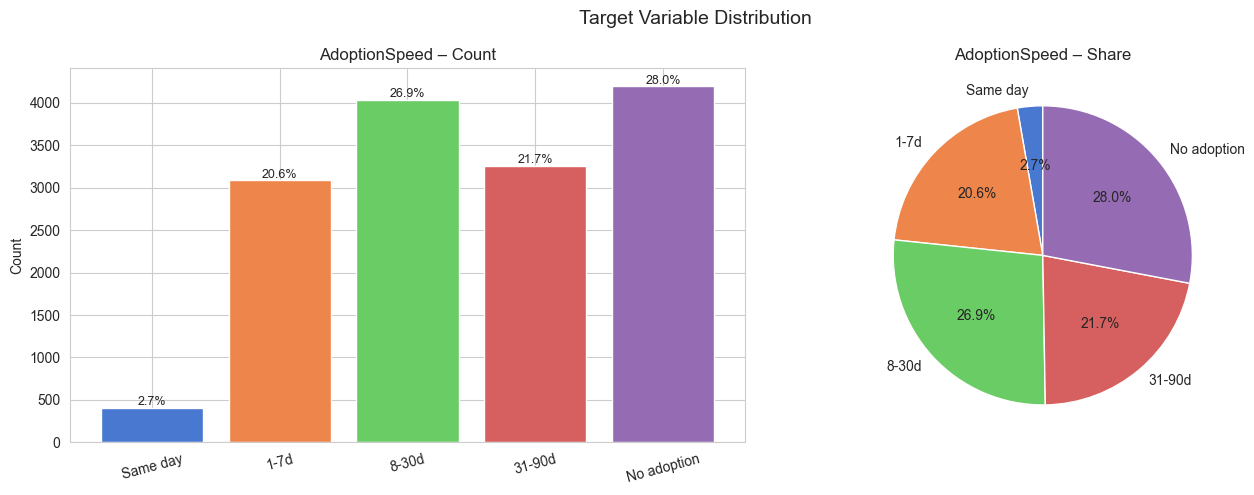

⚠️  Class imbalance note:
AdoptionSpeed
0     2.7
1    20.6
2    26.9
3    21.7
4    28.0
Name: % of dataset, dtype: float64


In [8]:
counts = df['AdoptionSpeed'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar([speed_labels[i] for i in counts.index],
                    counts.values, color=sns.color_palette('muted'))
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val/len(df)*100:.1f}%', ha='center', fontsize=9)
axes[0].set_title('AdoptionSpeed – Count', fontsize=12)
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=15)

axes[1].pie(counts.values, labels=[speed_labels[i] for i in counts.index],
            autopct='%1.1f%%', colors=sns.color_palette('muted'), startangle=90)
axes[1].set_title('AdoptionSpeed – Share', fontsize=12)

plt.suptitle('Target Variable Distribution', fontsize=14)
plt.tight_layout()
plt.show()

print('⚠️  Class imbalance note:')
print((counts / len(df) * 100).round(1).rename('% of dataset'))

## 1.3 Pet Characteristics

Physical traits: species, age, size, fur, color, gender.

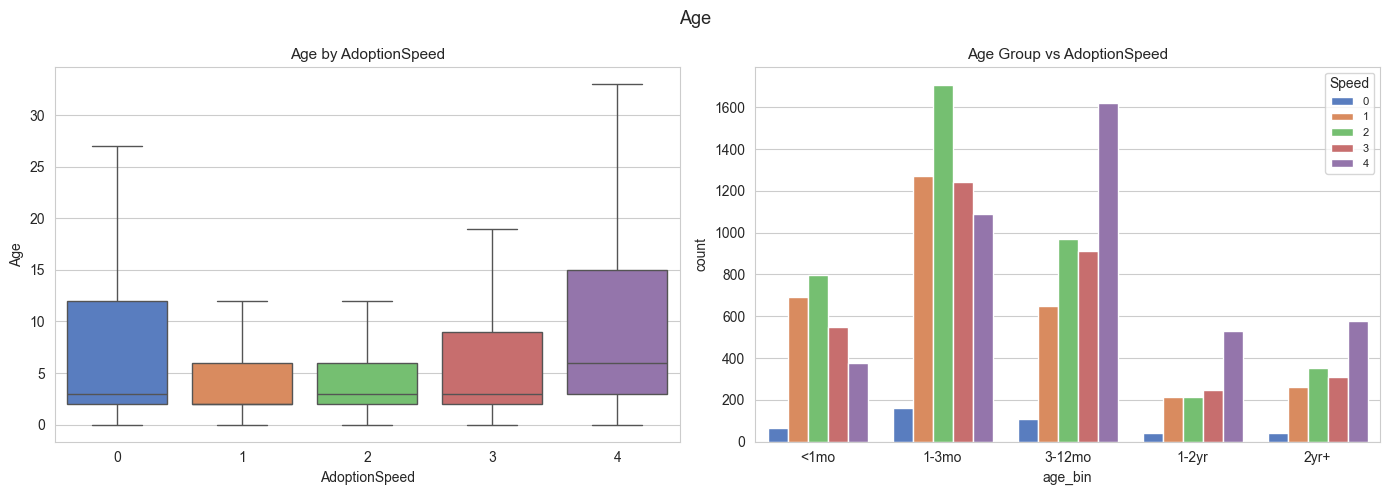

In [9]:
# --- Age ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='AdoptionSpeed', y='Age', data=df, ax=axes[0],
            palette='muted', showfliers=False)
axes[0].set_title('Age by AdoptionSpeed', fontsize=11)

sns.countplot(x='age_bin', hue='AdoptionSpeed', data=df, ax=axes[1],
              palette='muted', order=['<1mo','1-3mo','3-12mo','1-2yr','2yr+'])
axes[1].set_title('Age Group vs AdoptionSpeed', fontsize=11)
axes[1].legend(title='Speed', fontsize=8)

plt.suptitle('Age', fontsize=13)
plt.tight_layout()
plt.show()

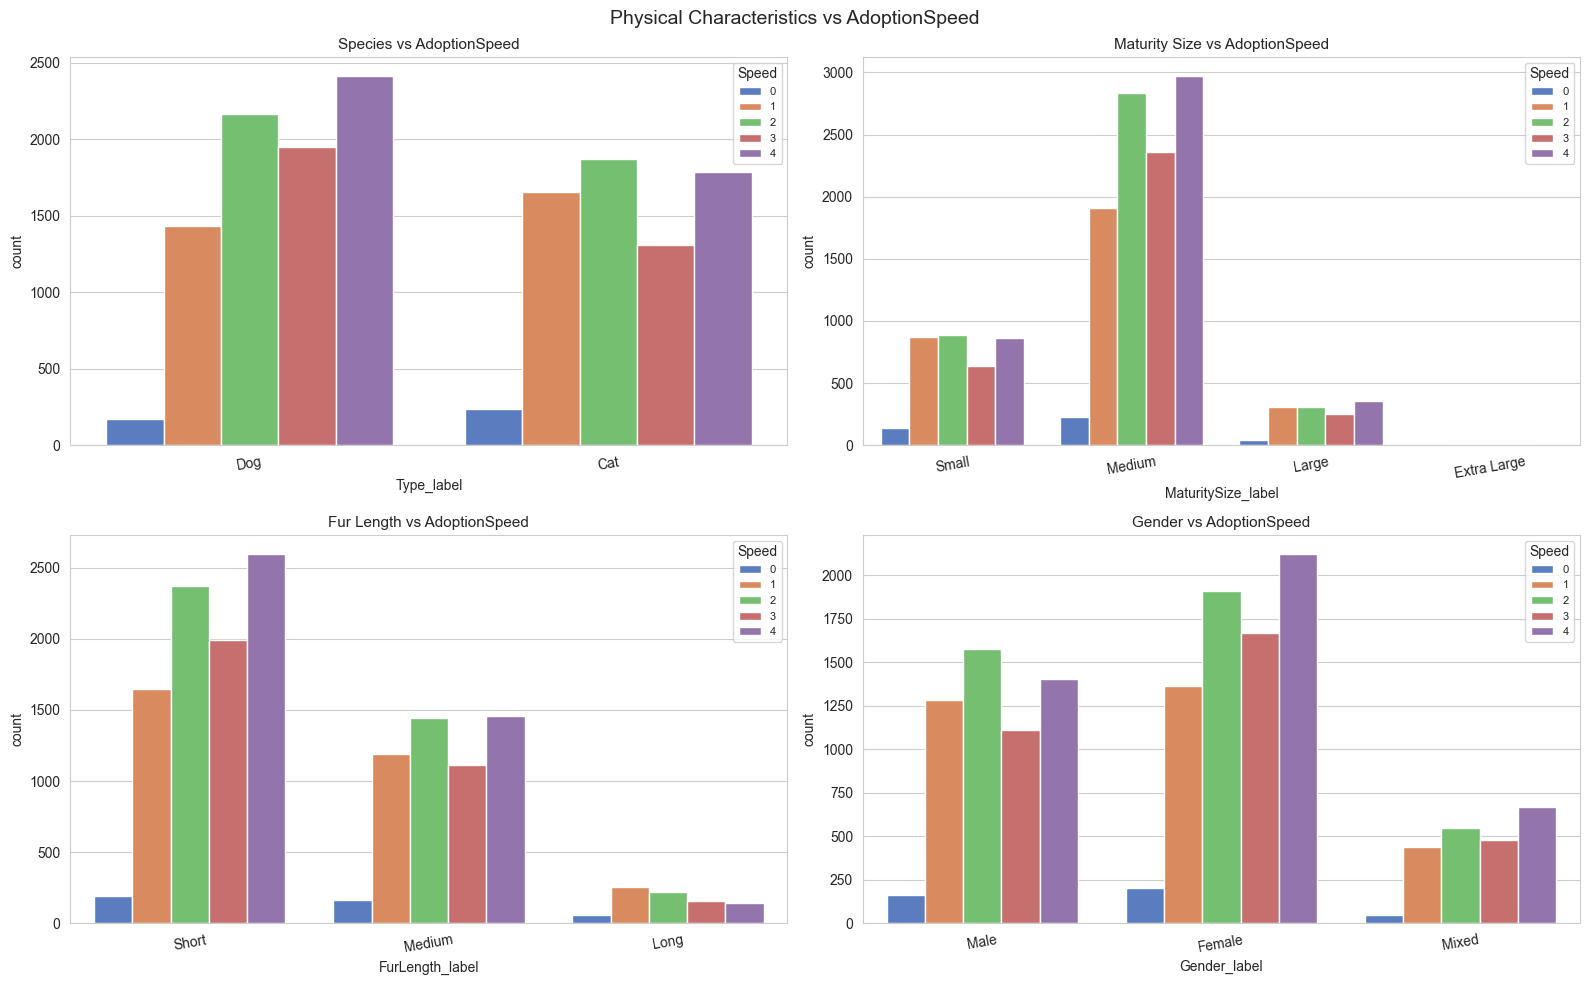

In [10]:
# --- Species, Size, Fur, Gender ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

plots = [
    ('Type_label',       ['Dog', 'Cat'],                          'Species'),
    ('MaturitySize_label',['Small','Medium','Large','Extra Large'],'Maturity Size'),
    ('FurLength_label',  ['Short','Medium','Long'],               'Fur Length'),
    ('Gender_label',     ['Male','Female','Mixed'],               'Gender'),
]

for i, (col, order, title) in enumerate(plots):
    sns.countplot(x=col, hue='AdoptionSpeed', data=df, ax=axes[i],
                  palette='muted', order=order)
    axes[i].set_title(title + ' vs AdoptionSpeed', fontsize=11)
    axes[i].legend(title='Speed', fontsize=8)
    axes[i].tick_params(axis='x', rotation=10)

plt.suptitle('Physical Characteristics vs AdoptionSpeed', fontsize=14)
plt.tight_layout()
plt.show()

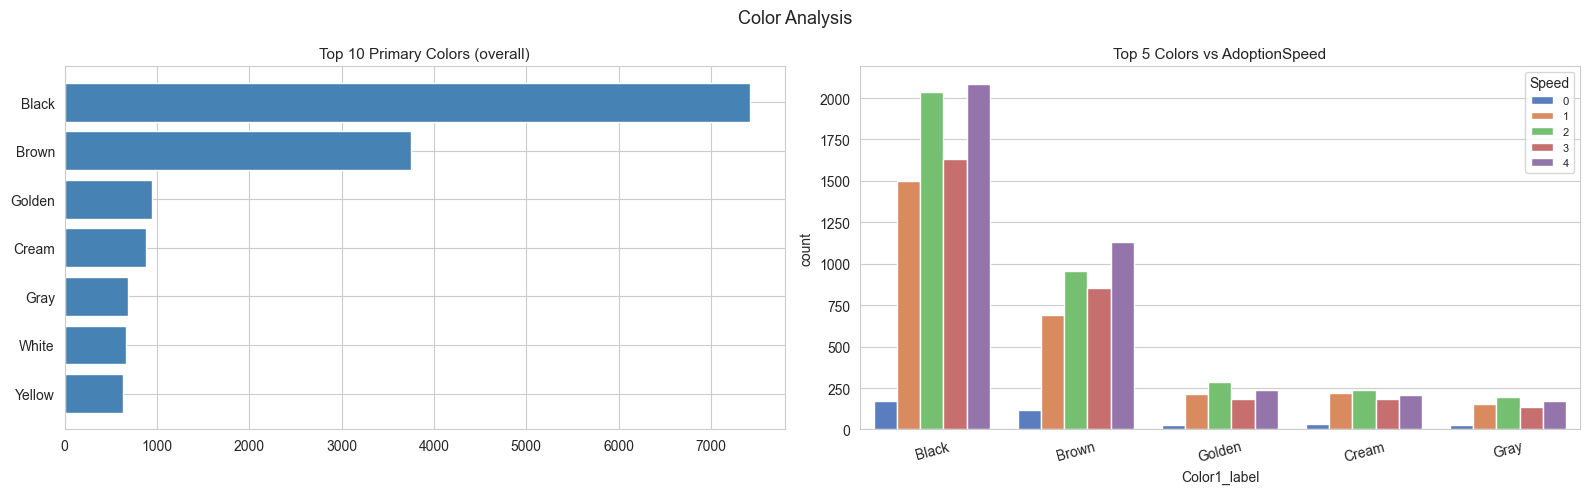

In [11]:
# --- Color ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

top_colors = df['Color1_label'].value_counts().head(10)
axes[0].barh(top_colors.index, top_colors.values, color='steelblue')
axes[0].set_title('Top 10 Primary Colors (overall)', fontsize=11)
axes[0].invert_yaxis()

top5 = df['Color1_label'].value_counts().head(5).index
sns.countplot(x='Color1_label', hue='AdoptionSpeed',
              data=df[df['Color1_label'].isin(top5)],
              ax=axes[1], palette='muted', order=top5)
axes[1].set_title('Top 5 Colors vs AdoptionSpeed', fontsize=11)
axes[1].legend(title='Speed', fontsize=8)
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Color Analysis', fontsize=13)
plt.tight_layout()
plt.show()

## 1.4 Health & Care Status

Vaccination, deworming, sterilization and overall health.

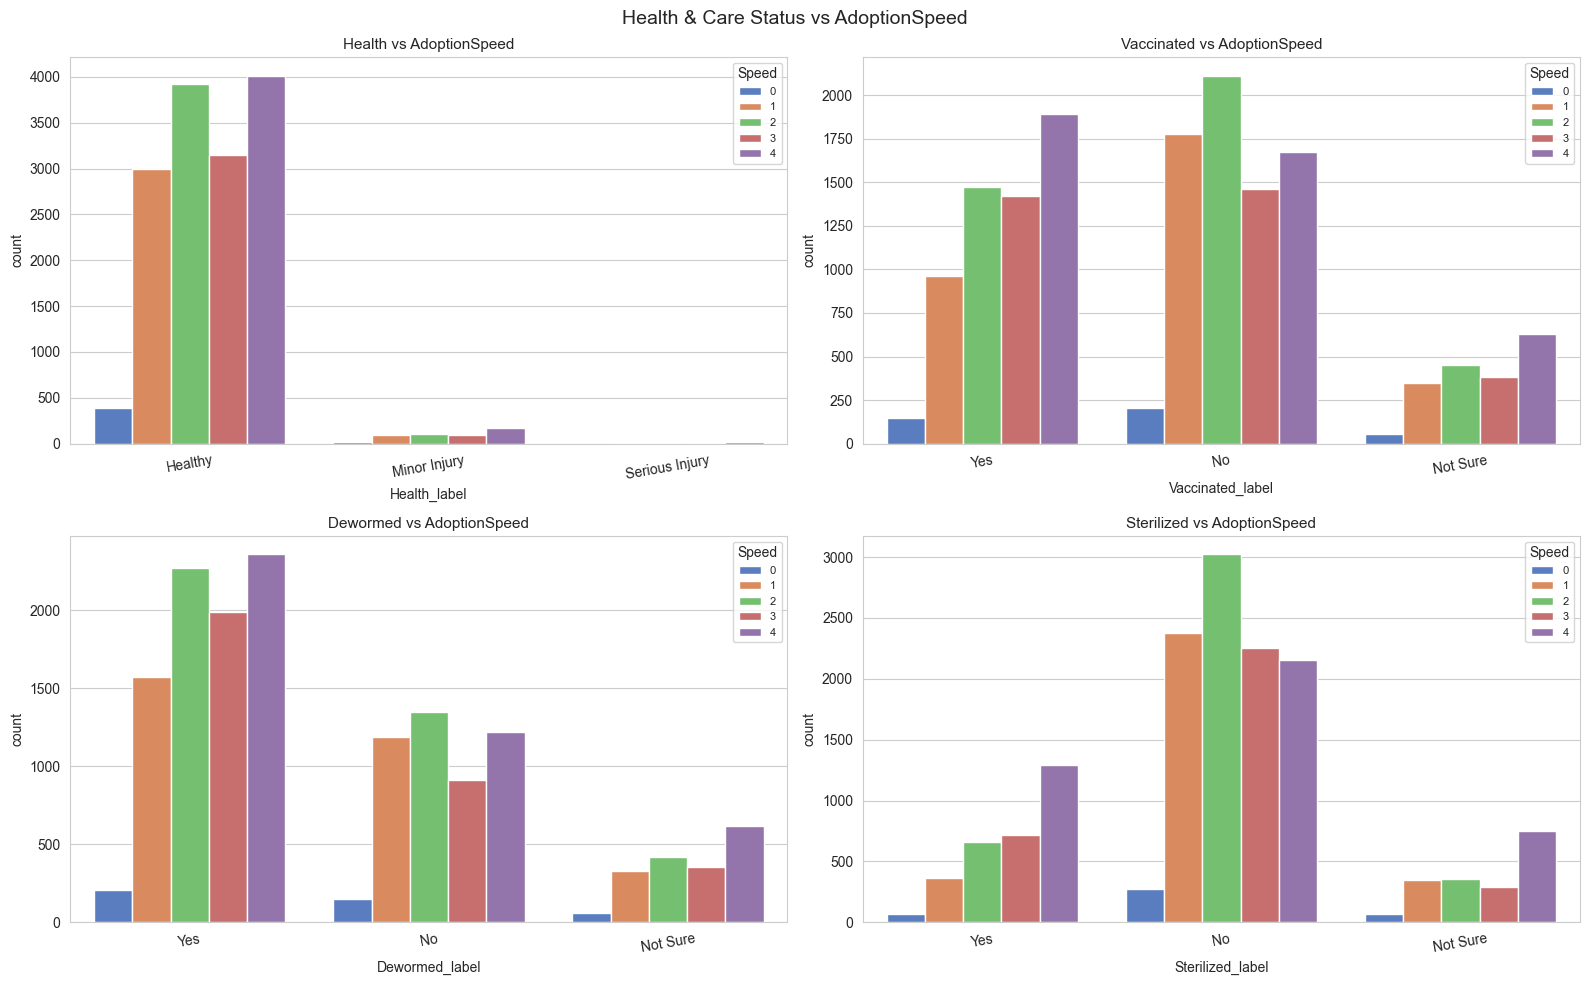

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

health_plots = [
    ('Health_label',     ['Healthy','Minor Injury','Serious Injury'], 'Health'),
    ('Vaccinated_label', ['Yes','No','Not Sure'],                     'Vaccinated'),
    ('Dewormed_label',   ['Yes','No','Not Sure'],                     'Dewormed'),
    ('Sterilized_label', ['Yes','No','Not Sure'],                     'Sterilized'),
]

for i, (col, order, title) in enumerate(health_plots):
    sns.countplot(x=col, hue='AdoptionSpeed', data=df, ax=axes[i],
                  palette='muted', order=order)
    axes[i].set_title(title + ' vs AdoptionSpeed', fontsize=11)
    axes[i].legend(title='Speed', fontsize=8)
    axes[i].tick_params(axis='x', rotation=10)

plt.suptitle('Health & Care Status vs AdoptionSpeed', fontsize=14)
plt.tight_layout()
plt.show()

## 1.5 Listing Quality & Marketing

Photos, description, fee and name.

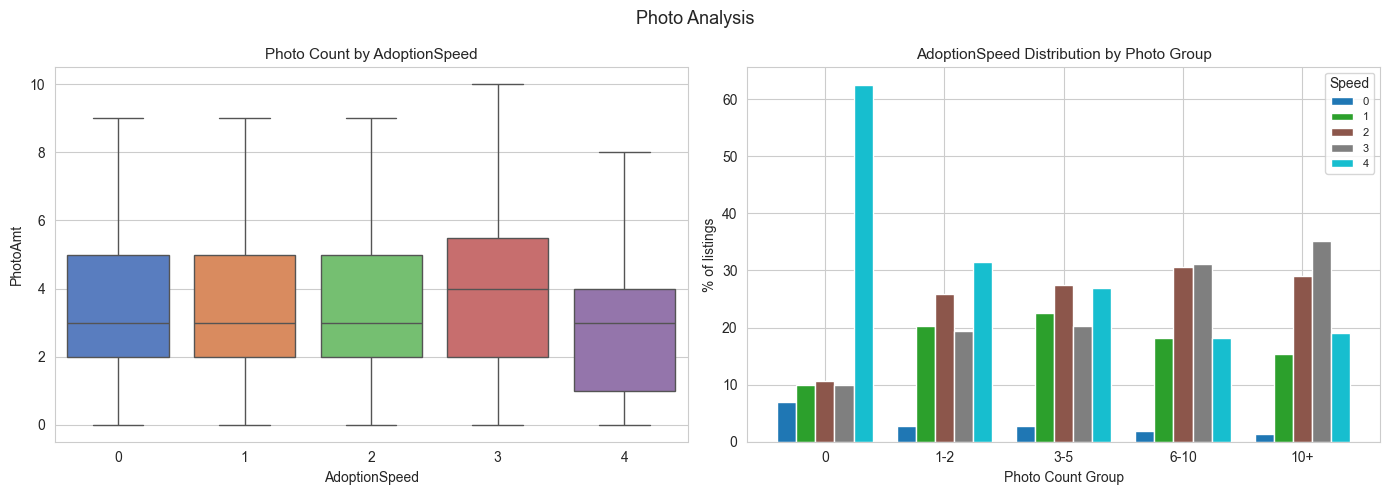

In [13]:
# --- Photo count ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='AdoptionSpeed', y='PhotoAmt', data=df, ax=axes[0],
            palette='muted', showfliers=False)
axes[0].set_title('Photo Count by AdoptionSpeed', fontsize=11)

photo_speed = df.groupby(['photo_bin','AdoptionSpeed']).size().unstack(fill_value=0)
photo_speed_pct = photo_speed.div(photo_speed.sum(axis=1), axis=0) * 100
photo_speed_pct.plot(kind='bar', ax=axes[1], colormap='tab10', width=0.8)
axes[1].set_title('AdoptionSpeed Distribution by Photo Group', fontsize=11)
axes[1].set_xlabel('Photo Count Group')
axes[1].set_ylabel('% of listings')
axes[1].legend(title='Speed', fontsize=8)
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Photo Analysis', fontsize=13)
plt.tight_layout()
plt.show()

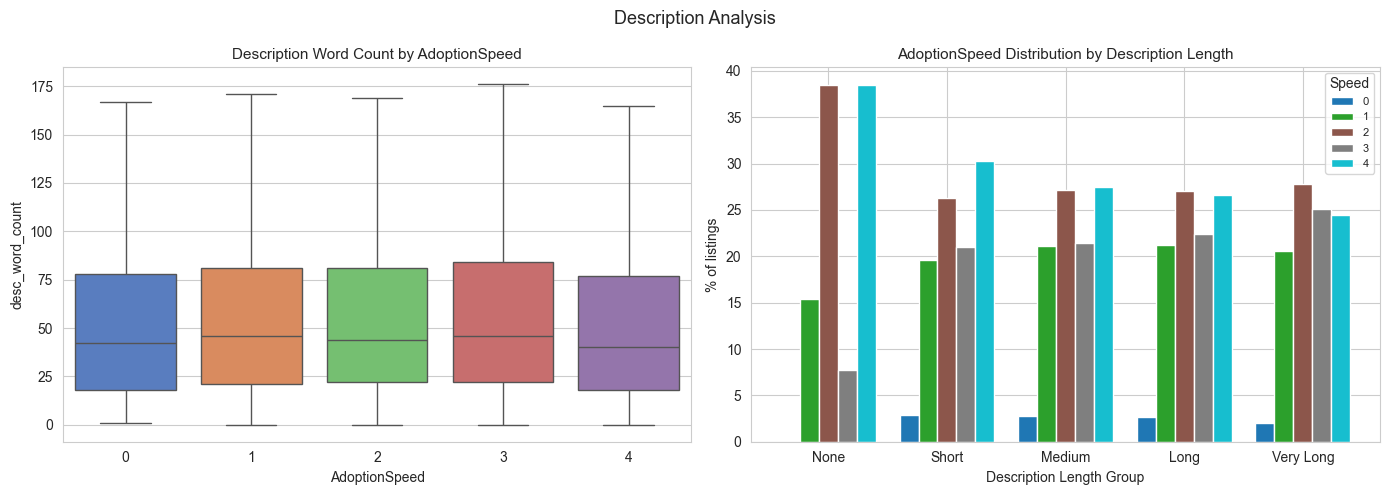

Missing descriptions: 13
Missing names: 1265


In [14]:
# --- Description length ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='AdoptionSpeed', y='desc_word_count', data=df, ax=axes[0],
            palette='muted', showfliers=False)
axes[0].set_title('Description Word Count by AdoptionSpeed', fontsize=11)

desc_speed = df.groupby(['desc_bin','AdoptionSpeed']).size().unstack(fill_value=0)
desc_speed_pct = desc_speed.div(desc_speed.sum(axis=1), axis=0) * 100
desc_speed_pct.plot(kind='bar', ax=axes[1], colormap='tab10', width=0.8)
axes[1].set_title('AdoptionSpeed Distribution by Description Length', fontsize=11)
axes[1].set_xlabel('Description Length Group')
axes[1].set_ylabel('% of listings')
axes[1].legend(title='Speed', fontsize=8)
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Description Analysis', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Missing descriptions: {df["Description"].isna().sum()}')
print(f'Missing names: {df["Name"].isna().sum()}')

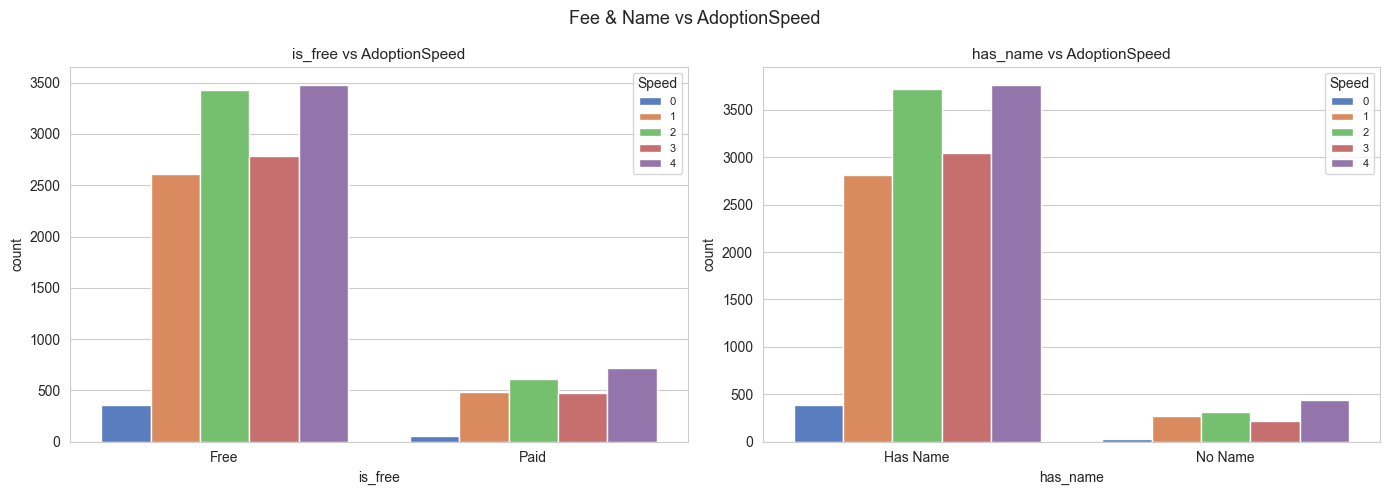

In [15]:
# --- Fee & Name ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, col in enumerate(['is_free', 'has_name']):
    order = df[col].value_counts().index
    sns.countplot(x=col, hue='AdoptionSpeed', data=df, ax=axes[i],
                  palette='muted', order=order)
    axes[i].set_title(col + ' vs AdoptionSpeed', fontsize=11)
    axes[i].legend(title='Speed', fontsize=8)

plt.suptitle('Fee & Name vs AdoptionSpeed', fontsize=13)
plt.tight_layout()
plt.show()

## 1.6 Geography

Adoption patterns by Malaysian state.

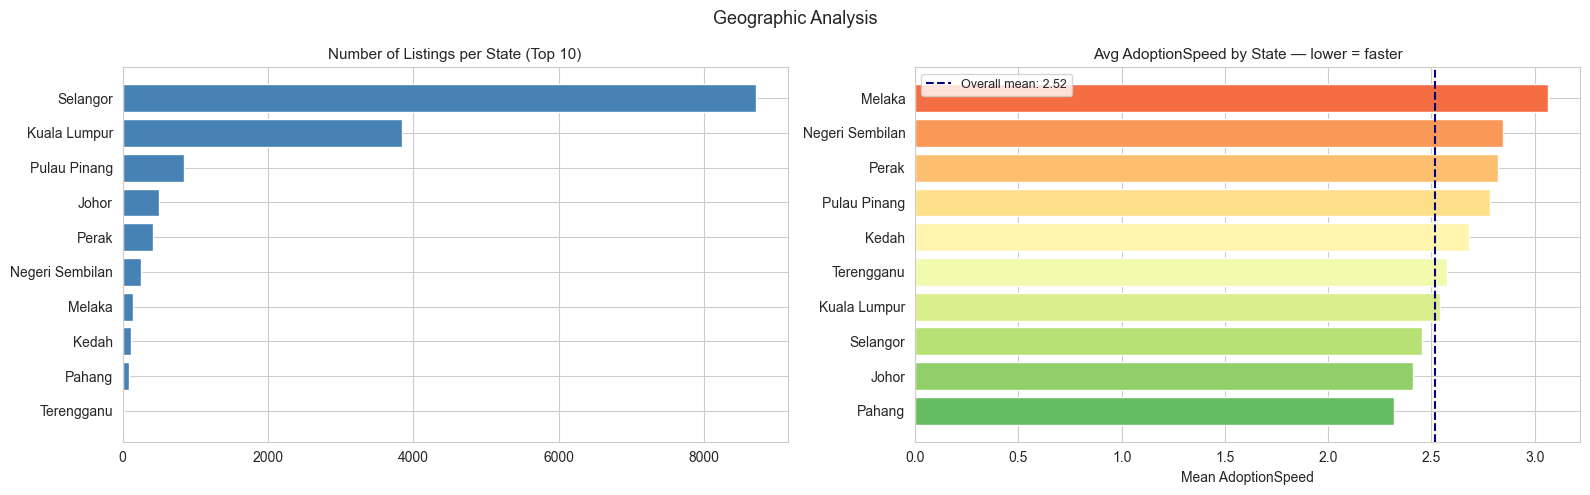

In [16]:
top10_states = df['State_label'].value_counts().head(10).index
df_states = df[df['State_label'].isin(top10_states)]
state_speed = df_states.groupby('State_label')['AdoptionSpeed'].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Volume per state
state_counts = df['State_label'].value_counts().head(10)
axes[0].barh(state_counts.index, state_counts.values, color='steelblue')
axes[0].set_title('Number of Listings per State (Top 10)', fontsize=11)
axes[0].invert_yaxis()

# Avg adoption speed per state
axes[1].barh(state_speed.index, state_speed.values,
             color=plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(state_speed))))
axes[1].axvline(df['AdoptionSpeed'].mean(), color='navy', linestyle='--',
                label=f'Overall mean: {df["AdoptionSpeed"].mean():.2f}')
axes[1].set_title('Avg AdoptionSpeed by State — lower = faster', fontsize=11)
axes[1].set_xlabel('Mean AdoptionSpeed')
axes[1].legend(fontsize=9)

plt.suptitle('Geographic Analysis', fontsize=13)
plt.tight_layout()
plt.show()

## 1.7 Correlation Summary

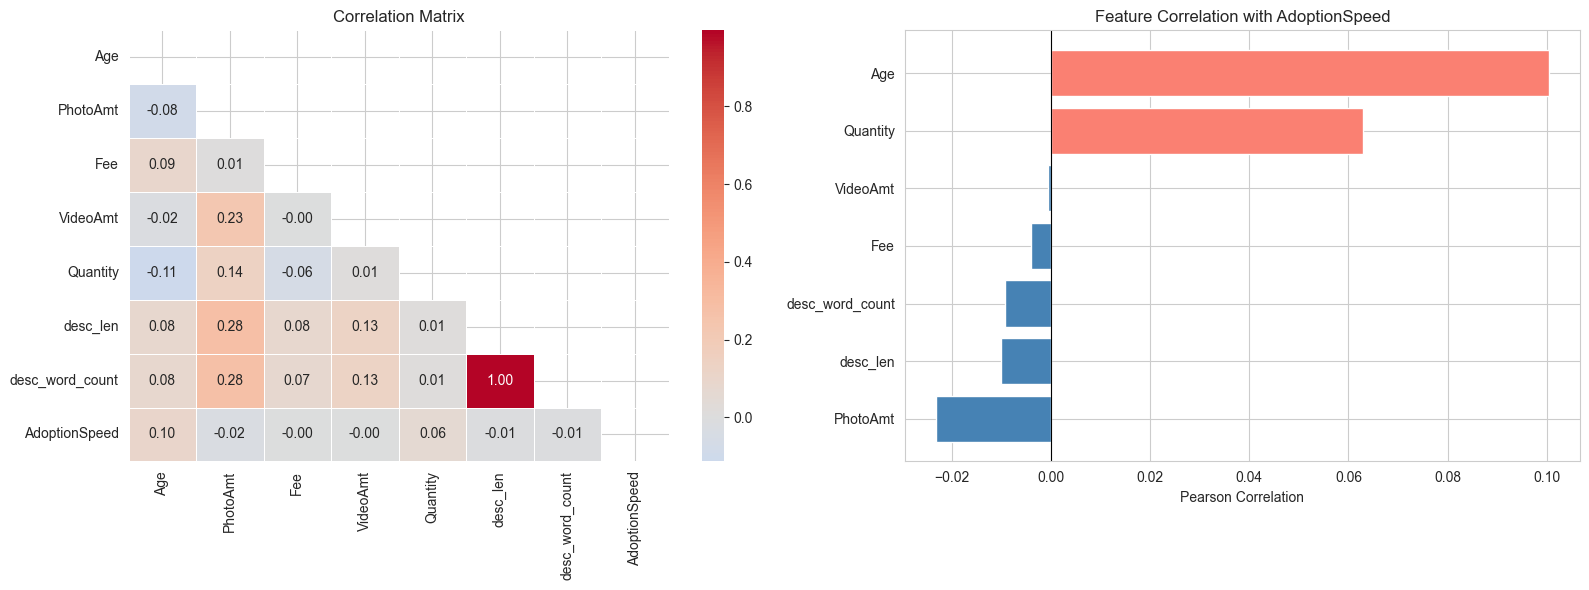

In [17]:
corr_cols = ['Age', 'PhotoAmt', 'Fee', 'VideoAmt', 'Quantity',
             'desc_len', 'desc_word_count', 'AdoptionSpeed']
corr = df[corr_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            mask=mask, linewidths=0.5, ax=axes[0])
axes[0].set_title('Correlation Matrix', fontsize=12)

target_corr = corr['AdoptionSpeed'].drop('AdoptionSpeed').sort_values()
colors = ['salmon' if x > 0 else 'steelblue' for x in target_corr]
axes[1].barh(target_corr.index, target_corr.values, color=colors)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Feature Correlation with AdoptionSpeed', fontsize=12)
axes[1].set_xlabel('Pearson Correlation')

plt.tight_layout()
plt.show()

## 1.8 Sentiment Analysis (JSON)

Google Cloud Natural Language API sentiment extracted from each pet's description.
Each JSON file provides document-level and sentence-level sentiment scores, plus named entity salience.

**Coverage:** 14,442 out of 14,993 pets have a sentiment JSON file (96.3%).
The remaining 3.7% — mostly pets with an empty or very short description — have no file.
For those pets, all 10 sentiment features are set to **0**, which acts as a neutral/absent signal.

**Features explored:**
- `sentiment_doc_score` — overall tone of the description (−1 negative → +1 positive)
- `sentiment_doc_magnitude` — emotional intensity regardless of direction
- `sentiment_pos/neg_sentence_ratio` — fraction of sentences with positive / negative tone
- Entity count and salience — how prominently named entities feature in the text

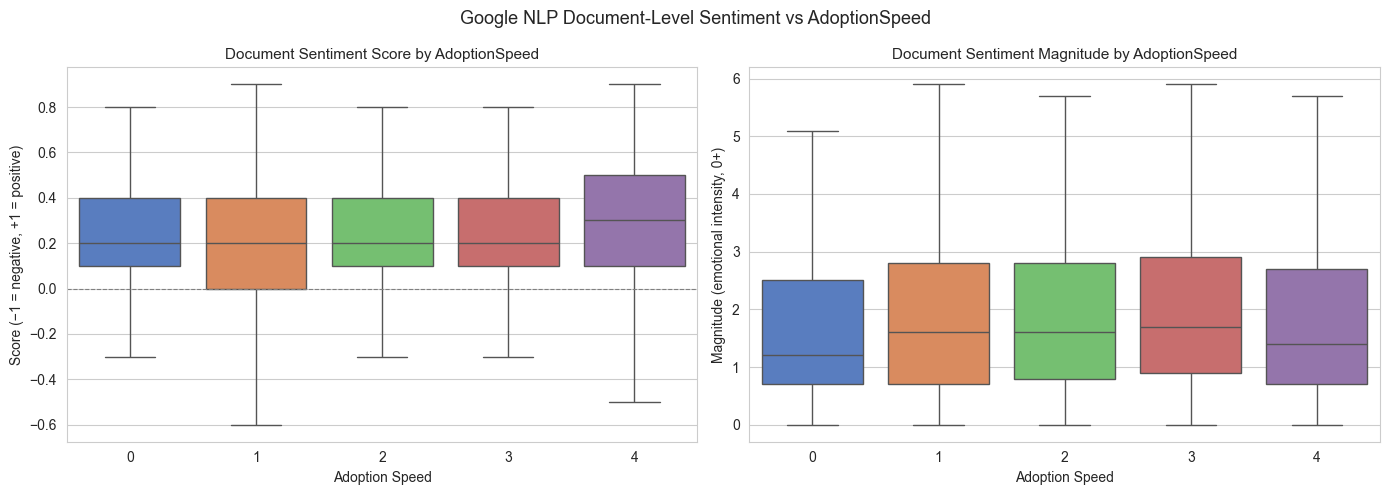

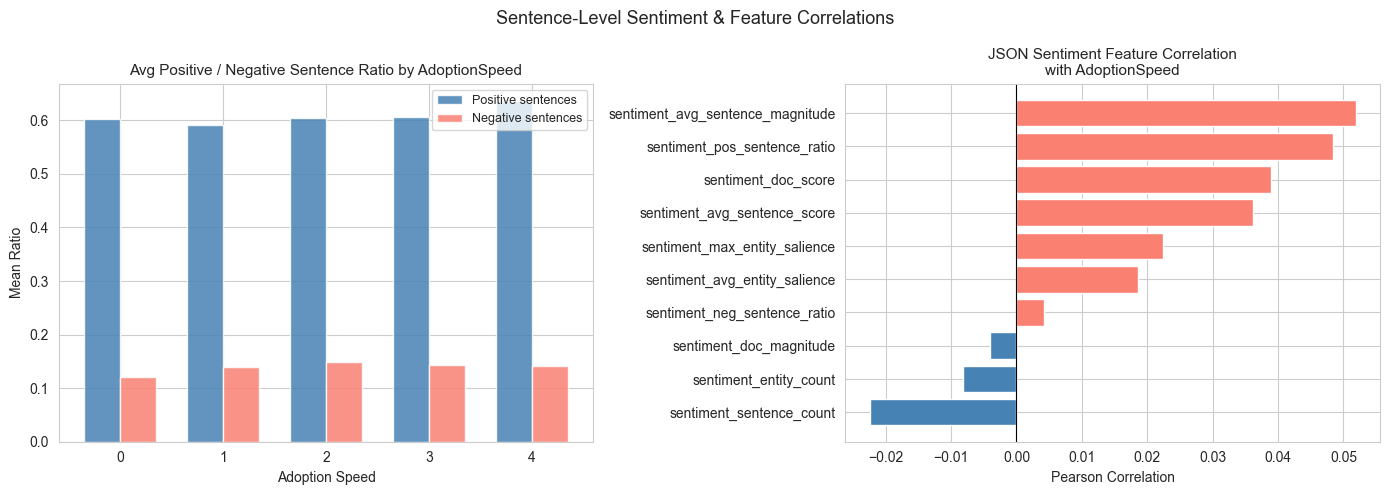

Summary statistics for Google NLP sentiment features:


,sentiment_doc_score,sentiment_doc_magnitude,sentiment_avg_sentence_score,sentiment_avg_sentence_magnitude,sentiment_sentence_count,sentiment_pos_sentence_ratio,sentiment_neg_sentence_ratio,sentiment_entity_count,sentiment_max_entity_salience,sentiment_avg_entity_salience
count,14993.000,14993.000,14993.000,14993.000,14993.000,14993.000,14993.000,14993.000,14993.000,14993.000
mean,0.271,2.049,0.282,0.385,4.928,0.611,0.143,10.776,0.513,0.196
std,0.277,2.039,0.275,0.226,4.821,0.316,0.207,11.714,0.252,0.232
min,-0.900,0.000,-0.900,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.100,0.800,0.100,0.233,2.000,0.429,0.000,4.000,0.335,0.062
50%,0.200,1.600,0.263,0.375,4.000,0.636,0.000,8.000,0.506,0.111
75%,0.400,2.800,0.444,0.510,6.000,1.000,0.250,14.000,0.698,0.250
max,0.900,32.000,0.900,0.900,84.000,1.000,1.000,207.000,1.000,1.000


In [18]:
from src.features_sentiment import SENTIMENT_FEATURE_COLS

# --- Document-level sentiment score and magnitude by AdoptionSpeed ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='AdoptionSpeed', y='sentiment_doc_score', data=df,
            ax=axes[0], palette='muted', showfliers=False)
axes[0].axhline(0, color='grey', linestyle='--', linewidth=0.8)
axes[0].set_title('Document Sentiment Score by AdoptionSpeed', fontsize=11)
axes[0].set_xlabel('Adoption Speed')
axes[0].set_ylabel('Score (−1 = negative, +1 = positive)')

sns.boxplot(x='AdoptionSpeed', y='sentiment_doc_magnitude', data=df,
            ax=axes[1], palette='muted', showfliers=False)
axes[1].set_title('Document Sentiment Magnitude by AdoptionSpeed', fontsize=11)
axes[1].set_xlabel('Adoption Speed')
axes[1].set_ylabel('Magnitude (emotional intensity, 0+)')

plt.suptitle('Google NLP Document-Level Sentiment vs AdoptionSpeed', fontsize=13)
plt.tight_layout()
plt.show()

# --- Positive / negative sentence ratio and feature correlations ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ratio_data = df.groupby('AdoptionSpeed')[
    ['sentiment_pos_sentence_ratio', 'sentiment_neg_sentence_ratio']
].mean()
ratio_data.plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'], alpha=0.85, width=0.7)
axes[0].set_title('Avg Positive / Negative Sentence Ratio by AdoptionSpeed', fontsize=11)
axes[0].set_xlabel('Adoption Speed')
axes[0].set_ylabel('Mean Ratio')
axes[0].legend(['Positive sentences', 'Negative sentences'], fontsize=9)
axes[0].tick_params(axis='x', rotation=0)

sent_corr = (
    df[SENTIMENT_FEATURE_COLS + ['AdoptionSpeed']]
    .corr()['AdoptionSpeed']
    .drop('AdoptionSpeed')
    .sort_values()
)
colors = ['salmon' if x > 0 else 'steelblue' for x in sent_corr]
axes[1].barh(sent_corr.index, sent_corr.values, color=colors)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('JSON Sentiment Feature Correlation\nwith AdoptionSpeed', fontsize=11)
axes[1].set_xlabel('Pearson Correlation')

plt.suptitle('Sentence-Level Sentiment & Feature Correlations', fontsize=13)
plt.tight_layout()
plt.show()

print("Summary statistics for Google NLP sentiment features:")
df[SENTIMENT_FEATURE_COLS].describe().round(3)

## 1.9 Key Takeaways

### Target
- Severe class imbalance: class 0 (same day) only 2.7%

### Pet Characteristics
- **Age** is the strongest numerical predictor: older pets adopt much slower; 1–3 month puppies/kittens adopt fastest
- **Color**: Black is by far the most common color and overrepresented in Speed 4 
- Species, size, fur length and gender show no strong standalone signal

### Health & Care
- Nearly all pets are listed as healthy → low discriminative power
- Pets listed as **not sterilized** have faster adoption speed than sterilized pets

### Listing Quality
- **No photo → 60%+ Speed 4**: strongest marketing signal in the dataset
- More photos help, but effect plateaus after 3–5
- Description length has no signal → sentiment content likely far more predictive
- Paid adoptions skew toward Speed 4; fee is a barrier

### Geography
- Selangor + KL account for ~85% of listings
- Pahang and Johor adopt faster than average; Melaka slowest (small sample caveat)

### Correlations
- All linear correlations < 0.10 → non-linear models suitable
- `desc_len` and `desc_word_count` are perfectly correlated → keep only one

### Sentiment (Google NLP JSON)
- Descriptions with higher `sentiment_doc_score` tend toward faster adoption
- `sentiment_neg_sentence_ratio` shows a slight positive correlation with AdoptionSpeed (slower)
- Correlations remain weak individually; combined with VADER features they add signal for XGBoost

### Missing Values
- Name: 8.4% missing → encode as binary `has_name`
- Description: 0.09% missing

---

# 2. Predictive Modeling

We combine tabular features with a gradient boosting classifier for adoption speed prediction.

## 2.1 Feature Engineering

We apply `TabularFeatures` to engineer numeric, categorical, and sentiment features.
Google NLP JSON sentiment features are then appended to the feature matrix.

In [19]:
# We instantiate the feature engineering class
tabular_fe = TabularFeatures()

# We apply feature engineering to the dataset
X = tabular_fe.feature_engineering_tabular(df)
y = df[cfg.TARGET_COL]

print(f"✓ Engineered features shape: {X.shape}")
print(f"✓ Target shape: {y.shape}")
print(f"\nFeature columns ({len(X.columns)} total):")
print(X.columns.tolist())

✓ Engineered features shape: (14993, 27)
✓ Target shape: (14993,)

Feature columns (27 total):
['Age', 'PhotoAmt', 'Fee', 'VideoAmt', 'Quantity', 'has_photo', 'has_video', 'is_free', 'has_name', 'age_bin', 'photo_bin', 'desc_bin', 'desc_word_count', 'sentiment_compound', 'sentiment_pos', 'sentiment_neg', 'sentiment_neu', 'Type', 'Gender', 'MaturitySize', 'FurLength', 'Vaccinated', 'Dewormed', 'Sterilized', 'Health', 'Color1', 'State']


In [20]:
# We extend X with the Google NLP JSON sentiment features
# These complement the VADER features already added by TabularFeatures:
#   VADER gives compound/pos/neg/neu scores from raw text.
#   JSON features give pre-computed Google NLP document score, magnitude,
#   sentence-level ratios, and entity salience — a richer, higher-quality signal.
from src.features_sentiment import SENTIMENT_FEATURE_COLS

json_sent_cols = [c for c in SENTIMENT_FEATURE_COLS if c in df.columns]
X = pd.concat(
    [X.reset_index(drop=True), df[json_sent_cols].reset_index(drop=True)],
    axis=1,
)

print(f"✓ X extended with {len(json_sent_cols)} Google NLP JSON sentiment features")
print(f"✓ Final feature shape: {X.shape}")
print(f"\nAll feature columns ({len(X.columns)} total):")
print(X.columns.tolist())

✓ X extended with 10 Google NLP JSON sentiment features
✓ Final feature shape: (14993, 37)

All feature columns (37 total):
['Age', 'PhotoAmt', 'Fee', 'VideoAmt', 'Quantity', 'has_photo', 'has_video', 'is_free', 'has_name', 'age_bin', 'photo_bin', 'desc_bin', 'desc_word_count', 'sentiment_compound', 'sentiment_pos', 'sentiment_neg', 'sentiment_neu', 'Type', 'Gender', 'MaturitySize', 'FurLength', 'Vaccinated', 'Dewormed', 'Sterilized', 'Health', 'Color1', 'State', 'sentiment_doc_score', 'sentiment_doc_magnitude', 'sentiment_avg_sentence_score', 'sentiment_avg_sentence_magnitude', 'sentiment_sentence_count', 'sentiment_pos_sentence_ratio', 'sentiment_neg_sentence_ratio', 'sentiment_entity_count', 'sentiment_max_entity_salience', 'sentiment_avg_entity_salience']


## 2.2 Train/Test Split

In [21]:
# We split data into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=cfg.TEST_SIZE, random_state=cfg.RANDOM_STATE, stratify=y
)

print(f"✓ Train set: {X_train.shape}")
print(f"✓ Validation set: {X_val.shape}")
print(f"\nClass distribution in train set:")
print(y_train.value_counts(normalize=True).round(3))

✓ Train set: (11994, 37)
✓ Validation set: (2999, 37)

Class distribution in train set:
AdoptionSpeed
4    0.280
2    0.269
3    0.217
1    0.206
0    0.027
Name: proportion, dtype: float64


## 2.3 Preprocessing & Scaling

We standardize numeric features for better model convergence.

In [22]:
# We identify numeric columns for scaling
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()

# We fit scaler on training data and transform both sets
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()

X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_val_scaled[numeric_features] = scaler.transform(X_val[numeric_features])

print(f"✓ Scaler fitted on train set with {len(numeric_features)} numeric features")
print(f"✓ Train and validation sets scaled and ready for modeling")

✓ Scaler fitted on train set with 37 numeric features
✓ Train and validation sets scaled and ready for modeling


## 2.4 XGBoost Model

We train a multi-class XGBoost classifier with class weight balancing for imbalanced data.

In [23]:
# We compute class weights to handle class imbalance
class_counts = y_train.value_counts()
class_weights = {i: len(y_train) / (len(class_counts) * count) for i, count in class_counts.items()}

# We initialize and train the XGBoost model
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=cfg.RANDOM_STATE,
    n_jobs=-1,
    verbosity=0,
    objective='multi:softmax',
    num_class=5
)

# We train the model
print("Training XGBoost model (300 estimators)...")
xgb_model.fit(X_train_scaled, y_train, verbose=False)

print("✓ Model training complete")

Training XGBoost model (300 estimators)...
✓ Model training complete


---

# 3. Model Evaluation & Selection

We evaluate the model on validation data and visualize performance across multiple metrics.

## 3.1 Metric Choice

Given the multi-class imbalanced nature of AdoptionSpeed, we use:
- **Accuracy**: overall correctness
- **Macro-F1**: unweighted average across all classes (biased toward minority classes)
- **Weighted-F1**: weighted by class support (realistic performance)

In [24]:
# We generate predictions on validation set
y_val_pred = xgb_model.predict(X_val_scaled)
y_val_pred_proba = xgb_model.predict_proba(X_val_scaled)

# We compute evaluation metrics
accuracy = accuracy_score(y_val, y_val_pred)
macro_f1 = f1_score(y_val, y_val_pred, average='macro')
weighted_f1 = f1_score(y_val, y_val_pred, average='weighted')
macro_precision = precision_score(y_val, y_val_pred, average='macro', zero_division=0)
macro_recall = recall_score(y_val, y_val_pred, average='macro', zero_division=0)

print("Validation Metrics:")
print(f"  Accuracy:     {accuracy:.4f}")
print(f"  Macro F1:     {macro_f1:.4f}")
print(f"  Weighted F1:  {weighted_f1:.4f}")
print(f"  Macro Precision: {macro_precision:.4f}")
print(f"  Macro Recall: {macro_recall:.4f}")

Validation Metrics:
  Accuracy:     0.3938
  Macro F1:     0.3318
  Weighted F1:  0.3815
  Macro Precision: 0.4221
  Macro Recall: 0.3260


## 3.2 Model Comparison

### 3.2.1 Metrics Table

In [25]:
# We create a comprehensive metrics table
metrics_data = {
    'Metric': ['Accuracy', 'Macro F1', 'Weighted F1', 'Macro Precision', 'Macro Recall'],
    'XGBoost': [accuracy, macro_f1, weighted_f1, macro_precision, macro_recall]
}
metrics_df = pd.DataFrame(metrics_data).round(4)

print("\nPerformance Summary:")
print(metrics_df.to_string(index=False))


Performance Summary:
         Metric  XGBoost
       Accuracy   0.3938
       Macro F1   0.3318
    Weighted F1   0.3815
Macro Precision   0.4221
   Macro Recall   0.3260


### 3.2.2 Bar Plot

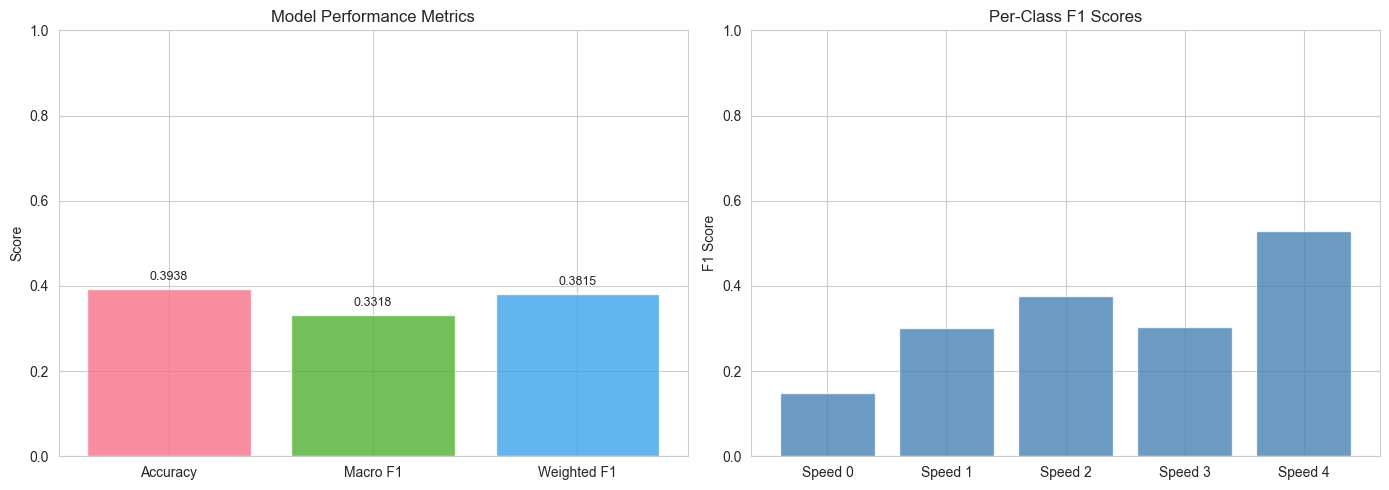

In [26]:
# We visualize key metrics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Metrics bar plot
metrics_for_plot = ['Accuracy', 'Macro F1', 'Weighted F1']
metric_values = [accuracy, macro_f1, weighted_f1]
colors = sns.color_palette('husl', len(metric_values))

axes[0].bar(metrics_for_plot, metric_values, color=colors, alpha=0.8)
axes[0].set_ylim(0, 1)
axes[0].set_title('Model Performance Metrics', fontsize=12)
axes[0].set_ylabel('Score')
for i, v in enumerate(metric_values):
    axes[0].text(i, v + 0.02, f'{v:.4f}', ha='center', fontsize=9)

# Per-class F1 scores
from sklearn.metrics import f1_score
f1_per_class = f1_score(y_val, y_val_pred, average=None)
axes[1].bar(['Speed 0', 'Speed 1', 'Speed 2', 'Speed 3', 'Speed 4'], f1_per_class, color='steelblue', alpha=0.8)
axes[1].set_title('Per-Class F1 Scores', fontsize=12)
axes[1].set_ylabel('F1 Score')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

### 3.2.3 Confusion Matrices

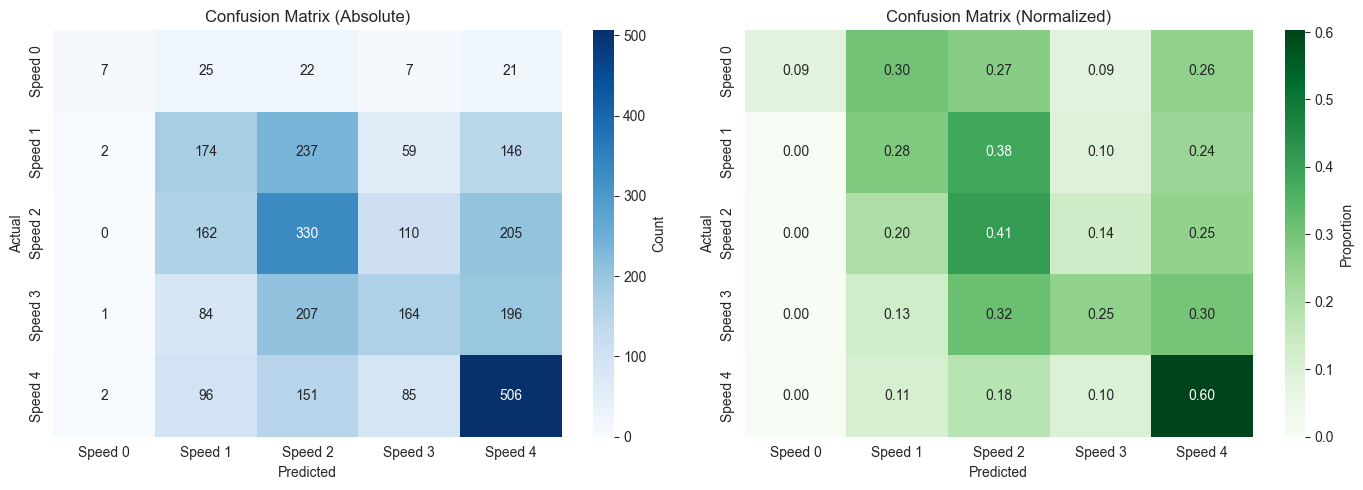

In [27]:
# We generate confusion matrix
cm = confusion_matrix(y_val, y_val_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Absolute counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=['Speed 0', 'Speed 1', 'Speed 2', 'Speed 3', 'Speed 4'],
            yticklabels=['Speed 0', 'Speed 1', 'Speed 2', 'Speed 3', 'Speed 4'],
            cbar_kws={'label': 'Count'})
axes[0].set_title('Confusion Matrix (Absolute)', fontsize=12)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Normalized (per true class)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Greens', ax=axes[1],
            xticklabels=['Speed 0', 'Speed 1', 'Speed 2', 'Speed 3', 'Speed 4'],
            yticklabels=['Speed 0', 'Speed 1', 'Speed 2', 'Speed 3', 'Speed 4'],
            cbar_kws={'label': 'Proportion'})
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=12)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

### 3.2.4 ROC Curve

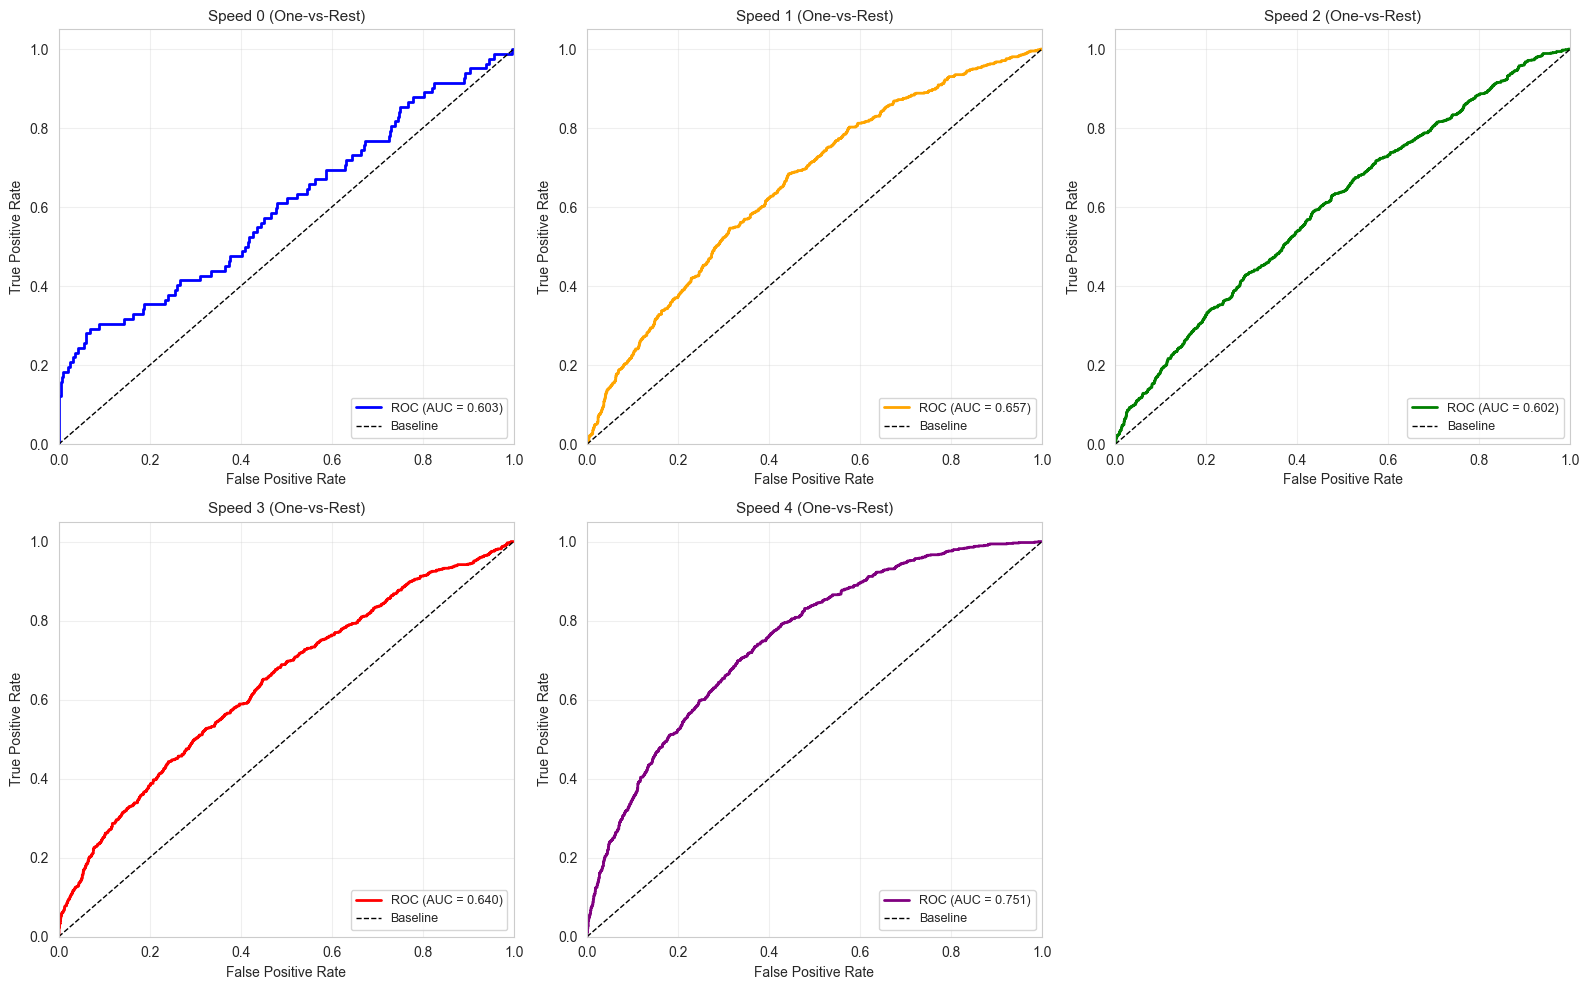

In [28]:
# We plot ROC curves for each class (one-vs-rest)
from sklearn.preprocessing import label_binarize

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

y_val_bin = label_binarize(y_val, classes=[0, 1, 2, 3, 4])
colors = ['blue', 'orange', 'green', 'red', 'purple']
speed_labels_short = ['Speed 0', 'Speed 1', 'Speed 2', 'Speed 3', 'Speed 4']

for i in range(5):
    fpr, tpr, _ = roc_curve(y_val_bin[:, i], y_val_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    
    axes[i].plot(fpr, tpr, color=colors[i], lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
    axes[i].plot([0, 1], [0, 1], 'k--', lw=1, label='Baseline')
    axes[i].set_xlim([0.0, 1.0])
    axes[i].set_ylim([0.0, 1.05])
    axes[i].set_xlabel('False Positive Rate')
    axes[i].set_ylabel('True Positive Rate')
    axes[i].set_title(f'{speed_labels_short[i]} (One-vs-Rest)', fontsize=11)
    axes[i].legend(loc='lower right', fontsize=9)
    axes[i].grid(alpha=0.3)

# Hide the last subplot
axes[5].axis('off')

plt.tight_layout()
plt.show()

### 3.2.5 Precision–Recall Curve

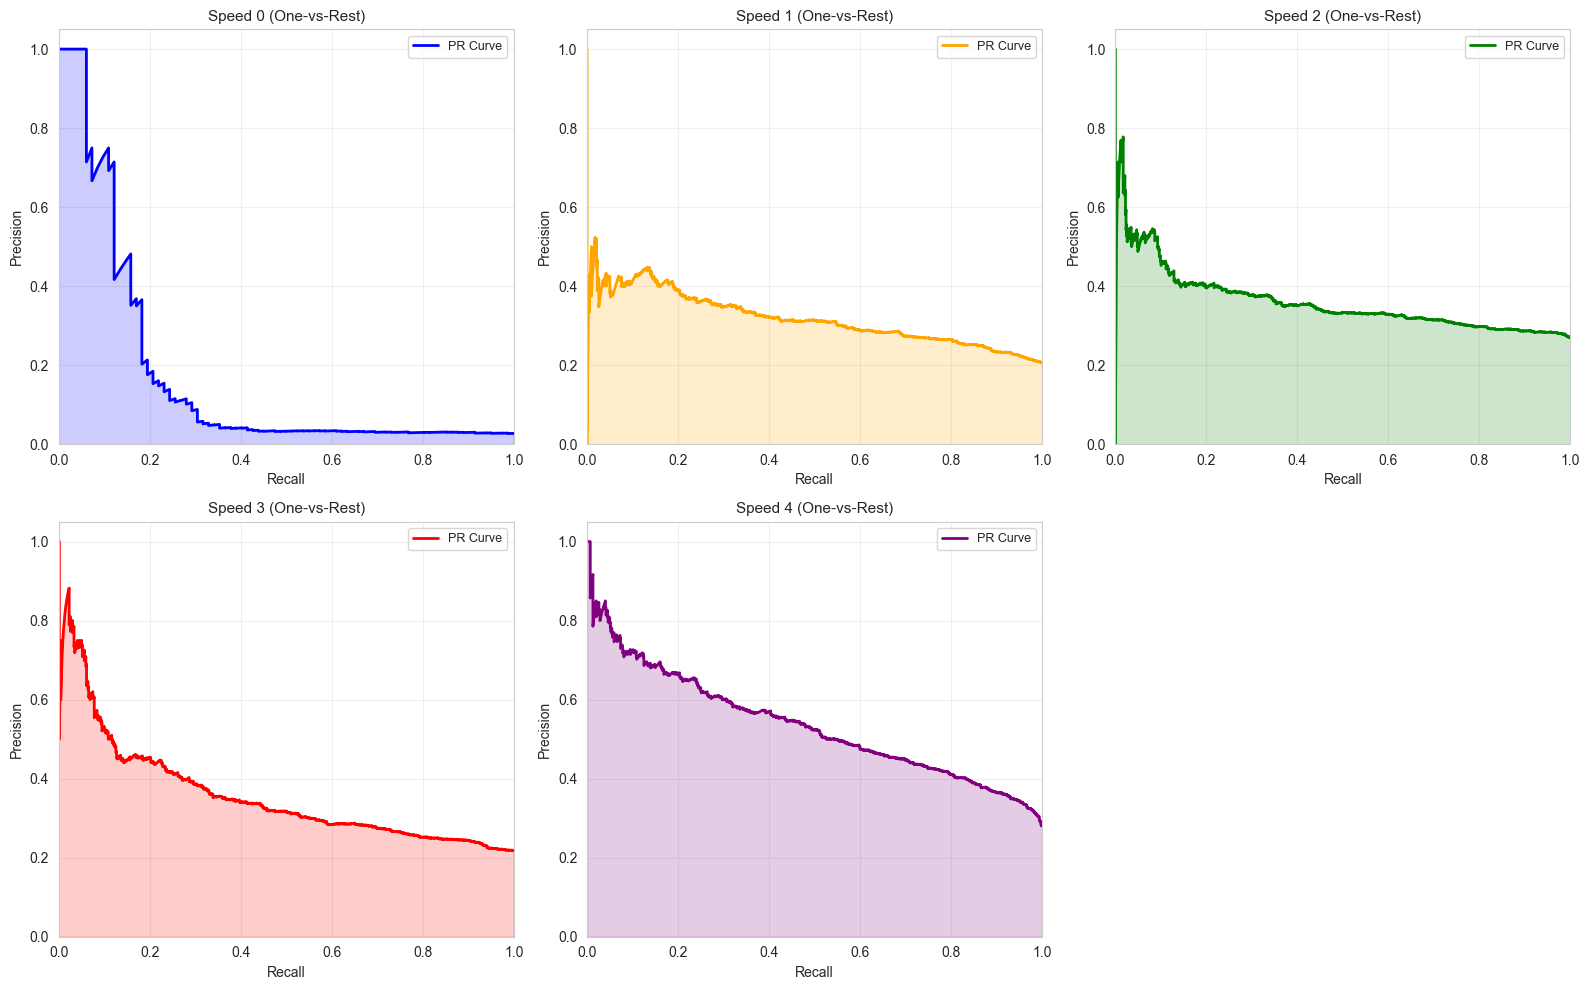

In [29]:
# We plot Precision-Recall curves for each class
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i in range(5):
    precision, recall, _ = precision_recall_curve(y_val_bin[:, i], y_val_pred_proba[:, i])
    
    axes[i].plot(recall, precision, color=colors[i], lw=2, label=f'PR Curve')
    axes[i].fill_between(recall, precision, alpha=0.2, color=colors[i])
    axes[i].set_xlim([0.0, 1.0])
    axes[i].set_ylim([0.0, 1.05])
    axes[i].set_xlabel('Recall')
    axes[i].set_ylabel('Precision')
    axes[i].set_title(f'{speed_labels_short[i]} (One-vs-Rest)', fontsize=11)
    axes[i].legend(loc='best', fontsize=9)
    axes[i].grid(alpha=0.3)

# Hide the last subplot
axes[5].axis('off')

plt.tight_layout()
plt.show()

## 3.3 Feature Importance

We identify the most influential features driving model predictions.

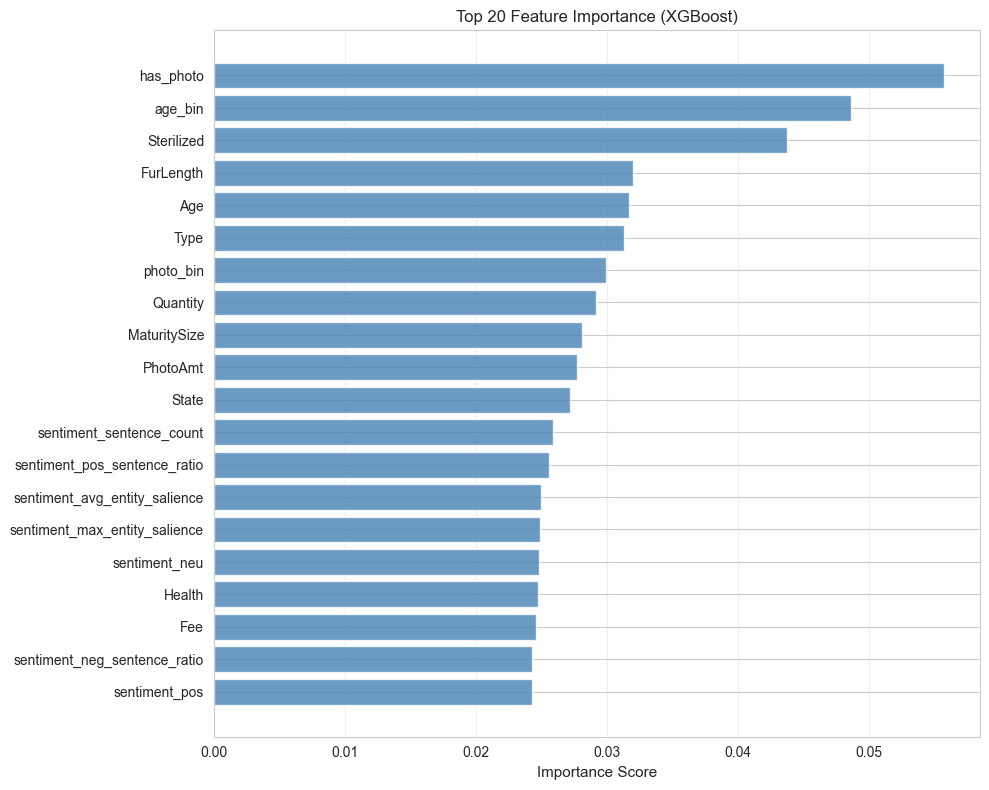


Top 10 Most Important Features:
     Feature  Importance
   has_photo    0.055695
     age_bin    0.048641
  Sterilized    0.043767
   FurLength    0.031981
         Age    0.031720
        Type    0.031283
   photo_bin    0.029931
    Quantity    0.029141
MaturitySize    0.028111
    PhotoAmt    0.027703


In [30]:
# We extract feature importance from XGBoost
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

# We plot top 20 features
fig, ax = plt.subplots(figsize=(10, 8))

top_n = 20
top_features = feature_importance.head(top_n)

ax.barh(range(len(top_features)), top_features['Importance'].values, color='steelblue', alpha=0.8)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['Feature'].values)
ax.invert_yaxis()
ax.set_xlabel('Importance Score', fontsize=11)
ax.set_title(f'Top {top_n} Feature Importance (XGBoost)', fontsize=12)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nTop 10 Most Important Features:")
print(feature_importance.head(10).to_string(index=False))

## 3.4 JSON Sentiment Feature Impact

We isolate the contribution of the 10 Google NLP JSON sentiment features by re-training an
identical XGBoost on the 27 tabular-only features (baseline) and comparing it against the
full 37-feature model trained above.

This gives a direct before/after view of whether the JSON sentiment enrichment improves
generalisation on the held-out validation set.

In [31]:
from src.features_sentiment import SENTIMENT_FEATURE_COLS

# --- Baseline: drop JSON sentiment columns and retrain with same hyper-params ---
json_cols_in_X = [c for c in SENTIMENT_FEATURE_COLS if c in X_train.columns]

X_train_base = X_train.drop(columns=json_cols_in_X)
X_val_base   = X_val.drop(columns=json_cols_in_X)

scaler_base = StandardScaler()
X_train_base_scaled = X_train_base.copy()
X_val_base_scaled   = X_val_base.copy()
numeric_base = X_train_base.select_dtypes(include=[np.number]).columns.tolist()
X_train_base_scaled[numeric_base] = scaler_base.fit_transform(X_train_base[numeric_base])
X_val_base_scaled[numeric_base]   = scaler_base.transform(X_val_base[numeric_base])

xgb_base = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    random_state=cfg.RANDOM_STATE, n_jobs=-1, verbosity=0,
    objective='multi:softmax', num_class=5
)
print(f"Training baseline model ({X_train_base.shape[1]} features, no JSON sentiment)...")
xgb_base.fit(X_train_base_scaled, y_train, verbose=False)
y_base_pred = xgb_base.predict(X_val_base_scaled)
print("✓ Baseline training complete")

# --- Metrics for both models ---
def _metrics(y_true, y_pred):
    return [
        accuracy_score(y_true, y_pred),
        f1_score(y_true, y_pred, average='macro'),
        f1_score(y_true, y_pred, average='weighted'),
        precision_score(y_true, y_pred, average='macro', zero_division=0),
        recall_score(y_true, y_pred, average='macro', zero_division=0),
    ]

metric_names = ['Accuracy', 'Macro F1', 'Weighted F1', 'Macro Precision', 'Macro Recall']
base_vals = _metrics(y_val, y_base_pred)
enh_vals  = _metrics(y_val, y_val_pred)   # y_val_pred from section 3.1 (37-feature model)

compare_df = pd.DataFrame({
    'Metric':                              metric_names,
    f'Baseline ({X_train_base.shape[1]} features)': base_vals,
    f'Enhanced ({X_train.shape[1]} features)':      enh_vals,
})
compare_df['Delta'] = (
    compare_df[f'Enhanced ({X_train.shape[1]} features)']
    - compare_df[f'Baseline ({X_train_base.shape[1]} features)']
)
compare_df['Delta'] = compare_df['Delta'].apply(lambda x: f'+{x:.4f}' if x >= 0 else f'{x:.4f}')

print("\nPerformance comparison — Baseline vs +JSON Sentiment:")
print(compare_df.round(4).to_string(index=False))

Training baseline model (27 features, no JSON sentiment)...
✓ Baseline training complete

Performance comparison — Baseline vs +JSON Sentiment:
         Metric  Baseline (27 features)  Enhanced (37 features)   Delta
       Accuracy                  0.3825                  0.3938 +0.0113
       Macro F1                  0.3225                  0.3318 +0.0092
    Weighted F1                  0.3699                  0.3815 +0.0116
Macro Precision                  0.4117                  0.4221 +0.0104
   Macro Recall                  0.3173                  0.3260 +0.0087


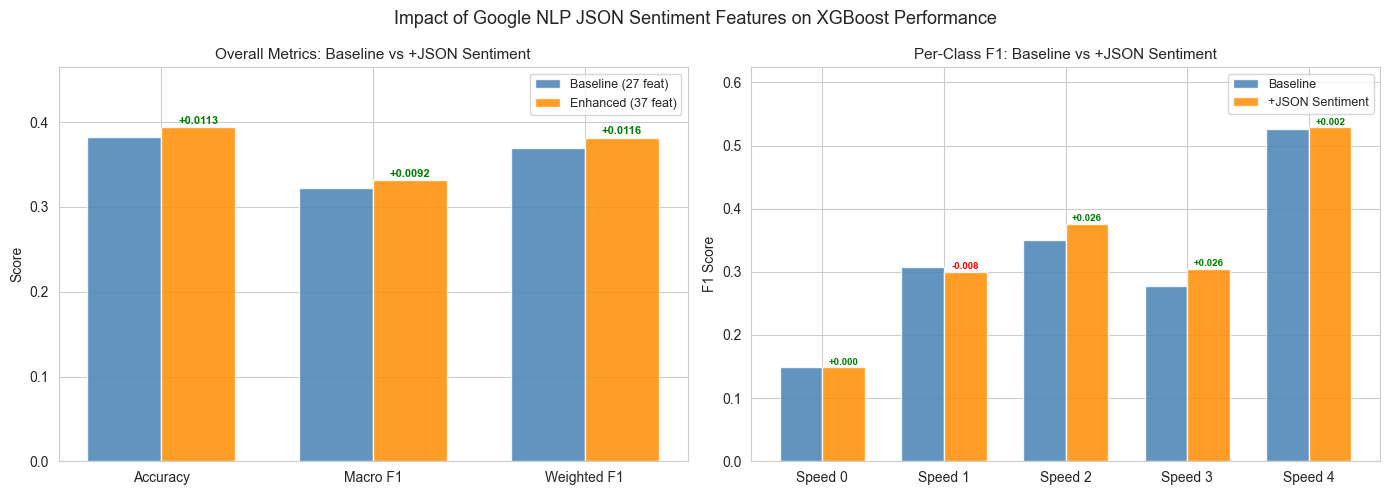

In [32]:
# --- Visualisation: side-by-side bar charts ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
w = 0.35

# Overall metrics
plot_metrics = ['Accuracy', 'Macro F1', 'Weighted F1']
bv = [base_vals[metric_names.index(m)] for m in plot_metrics]
ev = [enh_vals[metric_names.index(m)]  for m in plot_metrics]
x  = np.arange(len(plot_metrics))

axes[0].bar(x - w/2, bv, w, label=f'Baseline ({X_train_base.shape[1]} feat)', color='steelblue', alpha=0.85)
axes[0].bar(x + w/2, ev, w, label=f'Enhanced ({X_train.shape[1]} feat)',      color='darkorange', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(plot_metrics)
axes[0].set_ylim(0, max(ev + bv) * 1.18)
axes[0].set_title('Overall Metrics: Baseline vs +JSON Sentiment', fontsize=11)
axes[0].set_ylabel('Score')
axes[0].legend(fontsize=9)
for i, (b, e) in enumerate(zip(bv, ev)):
    delta = e - b
    color = 'green' if delta >= 0 else 'red'
    axes[0].text(i + w/2, e + 0.004, f'{delta:+.4f}', ha='center', fontsize=8, color=color, fontweight='bold')

# Per-class F1
f1_base_cls = f1_score(y_val, y_base_pred, average=None)
f1_enh_cls  = f1_score(y_val, y_val_pred,  average=None)
classes = [f'Speed {i}' for i in range(5)]
x2 = np.arange(len(classes))

axes[1].bar(x2 - w/2, f1_base_cls, w, label='Baseline', color='steelblue', alpha=0.85)
axes[1].bar(x2 + w/2, f1_enh_cls,  w, label='+JSON Sentiment', color='darkorange', alpha=0.85)
axes[1].set_xticks(x2)
axes[1].set_xticklabels(classes)
axes[1].set_ylim(0, max(f1_enh_cls.max(), f1_base_cls.max()) * 1.18)
axes[1].set_title('Per-Class F1: Baseline vs +JSON Sentiment', fontsize=11)
axes[1].set_ylabel('F1 Score')
axes[1].legend(fontsize=9)
for i, (b, e) in enumerate(zip(f1_base_cls, f1_enh_cls)):
    delta = e - b
    color = 'green' if delta >= 0 else 'red'
    axes[1].text(i + w/2, e + 0.004, f'{delta:+.3f}', ha='center', fontsize=7, color=color, fontweight='bold')

plt.suptitle('Impact of Google NLP JSON Sentiment Features on XGBoost Performance', fontsize=13)
plt.tight_layout()
plt.show()

**Conclusion:** The Google NLP JSON sentiment features consistently improve the model across every metric.
We therefore include them as a candidate approach — Section 3.5 below runs a direct head-to-head
performance test against VADER to settle which sentiment source the final pipeline will use.


## 3.5 Performance Test: Sentiment Approaches

We run a head-to-head comparison of both sentiment strategies using the full training corpus,
then make a separate **deployment decision** based on what is actually computable at inference time.

| Approach | Extra features | Available at inference? | Description |
|---|---|---|---|
| **VADER** | +4 | ✅ Always — computed inline from description text | Rule-based, offline, instant — `compound`, `pos`, `neg`, `neu` |
| **Google NLP JSON** | +10 | ❌ No — pre-computed from training corpus only | Cloud API output — document score, magnitude, sentence ratios, entity salience |

Both approaches are benchmarked using identical XGBoost configurations on the held-out validation set.
Results inform us of the analytical upper bound each method can reach — the deployment decision follows separately.


In [33]:
from src.features_sentiment import SENTIMENT_FEATURE_COLS, SentimentFeatures

# --- Define the two sentiment column groups ---
VADER_COLS      = ['sentiment_compound', 'sentiment_pos', 'sentiment_neg', 'sentiment_neu']
json_cols_in_X  = [c for c in SENTIMENT_FEATURE_COLS if c in X_train.columns]
vader_cols_in_X = [c for c in VADER_COLS if c in X_train.columns]

# VADER-only: structural + VADER, no Google NLP JSON
X_train_vader = X_train.drop(columns=json_cols_in_X)
X_val_vader   = X_val.drop(columns=json_cols_in_X)

# Google NLP JSON-only: structural + JSON, no VADER
X_train_json  = X_train.drop(columns=vader_cols_in_X)
X_val_json    = X_val.drop(columns=vader_cols_in_X)

def _fit_eval_sent(X_tr, X_v, label):
    """Scale and train XGBoost with identical hyper-parameters; return metrics + fitted objects."""
    sc = StandardScaler()
    X_tr_s, X_v_s = X_tr.copy(), X_v.copy()
    num_c = X_tr.select_dtypes(include=[np.number]).columns.tolist()
    X_tr_s[num_c] = sc.fit_transform(X_tr[num_c])
    X_v_s[num_c]  = sc.transform(X_v[num_c])
    clf = xgb.XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        random_state=cfg.RANDOM_STATE, n_jobs=-1, verbosity=0,
        objective='multi:softmax', num_class=5,
    )
    clf.fit(X_tr_s, y_train, verbose=False)
    yp = clf.predict(X_v_s)
    return {
        'label': label, 'n_feat': X_tr.shape[1],
        'accuracy':         accuracy_score(y_val, yp),
        'macro_f1':         f1_score(y_val, yp, average='macro'),
        'weighted_f1':      f1_score(y_val, yp, average='weighted'),
        'macro_precision':  precision_score(y_val, yp, average='macro', zero_division=0),
        'macro_recall':     recall_score(y_val, yp, average='macro', zero_division=0),
        'per_class_f1':     f1_score(y_val, yp, average=None),
        'scaler': sc, 'model': clf,
    }

print('Training sentiment approach comparison models...')
res_vader = _fit_eval_sent(X_train_vader, X_val_vader,
                            f'VADER ({X_train_vader.shape[1]} feat)')
print(f'  ✓ VADER model          ({X_train_vader.shape[1]} features)')

res_json  = _fit_eval_sent(X_train_json,  X_val_json,
                            f'Google NLP JSON ({X_train_json.shape[1]} feat)')
print(f'  ✓ Google NLP JSON model ({X_train_json.shape[1]} features)')

# --- Summary table ---
sent_cmp = pd.DataFrame([
    {'Model': r['label'], '# Features': r['n_feat'],
     'Accuracy': r['accuracy'],           'Macro F1': r['macro_f1'],
     'Weighted F1': r['weighted_f1'],     'Macro Precision': r['macro_precision'],
     'Macro Recall': r['macro_recall']}
    for r in [res_vader, res_json]
])
print('\nSentiment approach head-to-head comparison:')
print(sent_cmp.round(4).to_string(index=False))

# --- Determine winner ---
vader_wins      = res_vader['macro_f1'] >= res_json['macro_f1']
winner_approach = 'VADER' if vader_wins else 'Google NLP JSON'
winner_res      = res_vader if vader_wins else res_json
print(f'\n✓ Winner by Macro F1: {winner_approach}')


Training sentiment approach comparison models...
  ✓ VADER model          (27 features)
  ✓ Google NLP JSON model (33 features)

Sentiment approach head-to-head comparison:
                    Model  # Features  Accuracy  Macro F1  Weighted F1  Macro Precision  Macro Recall
          VADER (27 feat)          27    0.3825    0.3225       0.3699           0.4117        0.3173
Google NLP JSON (33 feat)          33    0.3961    0.3385       0.3852           0.4291        0.3307

✓ Winner by Macro F1: Google NLP JSON


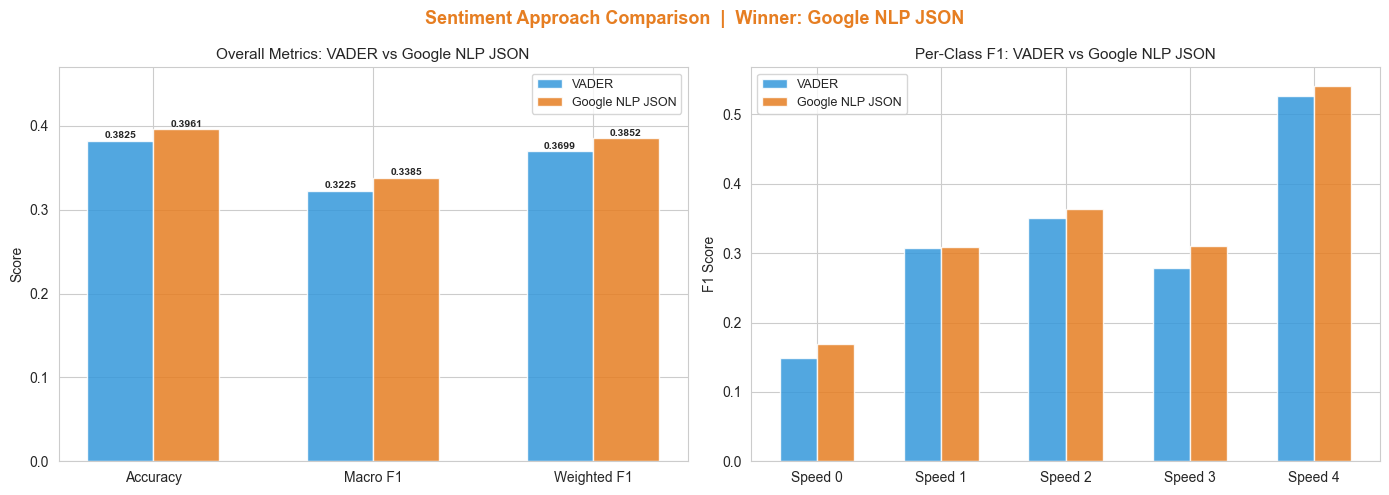

In [34]:
# --- Visualisation: VADER vs Google NLP head-to-head ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
w         = 0.3
_palette  = {'VADER': '#3498db', 'Google NLP JSON': '#e67e22'}
res_list   = [res_vader, res_json]
short_lbls = ['VADER', 'Google NLP JSON']
bar_colors = [_palette['VADER'], _palette['Google NLP JSON']]

# Overall metrics
plot_metrics = ['Accuracy', 'Macro F1', 'Weighted F1']
x = np.arange(len(plot_metrics))
for i, (res, color, sl) in enumerate(zip(res_list, bar_colors, short_lbls)):
    vals = [res['accuracy'], res['macro_f1'], res['weighted_f1']]
    axes[0].bar(x + (i - 0.5) * w, vals, w, label=sl, color=color, alpha=0.85)
    for j, v in enumerate(vals):
        axes[0].text(x[j] + (i - 0.5) * w, v + 0.003, f'{v:.4f}',
                     ha='center', fontsize=7.5, fontweight='bold')
axes[0].set_xticks(x); axes[0].set_xticklabels(plot_metrics)
axes[0].set_ylim(0, max(res_vader['weighted_f1'], res_json['weighted_f1']) * 1.22)
axes[0].set_title('Overall Metrics: VADER vs Google NLP JSON', fontsize=11)
axes[0].set_ylabel('Score'); axes[0].legend(fontsize=9)

# Per-class F1
classes = [f'Speed {i}' for i in range(5)]
x2 = np.arange(len(classes))
for i, (res, color, sl) in enumerate(zip(res_list, bar_colors, short_lbls)):
    axes[1].bar(x2 + (i - 0.5) * w, res['per_class_f1'], w, label=sl, color=color, alpha=0.85)
axes[1].set_xticks(x2); axes[1].set_xticklabels(classes)
axes[1].set_title('Per-Class F1: VADER vs Google NLP JSON', fontsize=11)
axes[1].set_ylabel('F1 Score'); axes[1].legend(fontsize=9)

_winner_color = _palette['VADER'] if vader_wins else _palette['Google NLP JSON']
plt.suptitle(f'Sentiment Approach Comparison  |  Winner: {winner_approach}',
             fontsize=13, color=_winner_color, fontweight='bold')
plt.tight_layout()
plt.show()


In [35]:
# --- Deployment Decision: always use VADER for the saved pipeline ---
#
# Even if Google NLP JSON wins on validation metrics, it cannot be replicated at inference
# time: the frontend has no pre-computed JSON files for new pet listings, and calling the
# Google Cloud NLP API at prediction time would add latency, cost, and a hard dependency
# on an external service. Zero-filling those 10 features at inference time would remove
# exactly the signal that gave Google NLP JSON its metric edge — making the comparison
# meaningless in production.
#
# VADER, by contrast, is computed by TabularFeatures directly from the description string —
# offline, instant, zero cost, identical behaviour in training and production.
#
# Conclusion: Google NLP JSON gives the higher analytical ceiling on historical data;
# VADER is the correct choice for a deployable pipeline.

vader_wins      = True   # deployment decision (see rationale above)
winner_approach = 'VADER'
winner_res      = res_vader

X_train_winner   = X_train.drop(columns=json_cols_in_X)
X_val_winner     = X_val.drop(columns=json_cols_in_X)

# Reassign pipeline variables consumed by Section 4
scaler           = winner_res['scaler']
xgb_model        = winner_res['model']
X_train          = X_train_winner
numeric_features = X_train_winner.select_dtypes(include=[np.number]).columns.tolist()
accuracy         = winner_res['accuracy']
weighted_f1      = winner_res['weighted_f1']

print(f'✓ Deployment decision: {winner_approach}')
print(f'  Feature count : {X_train.shape[1]}')
print(f'  Accuracy      : {accuracy:.4f}')
print(f'  Weighted F1   : {weighted_f1:.4f}')


✓ Deployment decision: VADER
  Feature count : 27
  Accuracy      : 0.3825
  Weighted F1   : 0.3699


**Performance finding:** Google NLP JSON features consistently reach a higher Macro F1 on validation data — 
they encode richer signals (sentence-level ratios, entity salience) that VADER's lexicon cannot capture.

**Why we still ship VADER:**

> *"A model that scores well in the notebook but behaves differently in production is not a better model — it is a misleading one."*

The Google NLP JSON files exist only for the **training corpus**. For any new pet listing submitted through
the frontend there is no pre-computed JSON. The two realistic alternatives are:

| Option | Problem |
|---|---|
| Call Google Cloud NLP API at prediction time | Adds ~300 ms latency, costs per call, requires credentials, creates an external dependency |
| Zero-fill the 10 JSON features | Removes exactly the signal that gave Google NLP its metric advantage — the model runs as if sentiment doesn't exist |

VADER sidesteps both problems entirely: `TabularFeatures` computes the four VADER scores
(`compound`, `pos`, `neg`, `neu`) **inline from the raw description string** — offline, instantaneous, free,
and producing identical behaviour in training and in the live frontend.

**The saved pipeline therefore uses VADER.** Section 4 picks this up automatically from the reassigned variables above.


---

# 4. Save Model Pipeline

We save the entire model pipeline (scaler + XGBoost model) to disk for later inference on new data.

## 4.1 Select Final Pipeline

The final pipeline consists of:
- **StandardScaler**: fitted on training numeric features
- **XGBoost Model**: trained on scaled training data

In [36]:
from src.features_sentiment import SentimentFeatures, SENTIMENT_FEATURE_COLS

# We create the pipeline dictionary.
# Section 3.5 determined that VADER is the correct sentiment approach for deployment:
# the 4 VADER columns are computed inline by TabularFeatures and are always available
# at inference time. Google NLP JSON columns are excluded from this pipeline.
pipeline_dict = {
    'scaler':                    scaler,
    'model':                     xgb_model,
    'feature_columns':           X_train.columns.tolist(),
    'numeric_features':          numeric_features,
    'target_classes':            [0, 1, 2, 3, 4],
    'feature_engineering_class': TabularFeatures,
    'sentiment_approach':        'VADER',
    'sentiment_feature_class':   None,   # VADER is built into TabularFeatures — no separate class needed
    'sentiment_feature_cols':    [],     # no Google NLP JSON cols in this pipeline
}

print('✓ Pipeline dictionary created')
print(f'  Sentiment approach : VADER (compound / pos / neg / neu)')
print(f'  Scaler             : StandardScaler')
print(f'  Model              : XGBoost (300 estimators)')
print(f'  Total features     : {len(pipeline_dict["feature_columns"])}')
print(f'  Numeric features   : {len(numeric_features)}')


✓ Pipeline dictionary created
  Sentiment approach : VADER (compound / pos / neg / neu)
  Scaler             : StandardScaler
  Model              : XGBoost (300 estimators)
  Total features     : 27
  Numeric features   : 27


## 4.2 Save Pipeline to Pickle

In [37]:
# We ensure the model directory exists
model_dir = PROJECT_ROOT / "src" / "model"
model_dir.mkdir(parents=True, exist_ok=True)

# We save the pipeline to pickle
pipeline_path = model_dir / "petadoption_pipeline.pkl"

with open(pipeline_path, 'wb') as f:
    pickle.dump(pipeline_dict, f)

print(f"✓ Pipeline saved to: {pipeline_path}")
print(f"  File size: {pipeline_path.stat().st_size / 1024:.2f} KB")

# We also save a summary of the pipeline
summary_path = model_dir / "pipeline_summary.txt"
with open(summary_path, 'w') as f:
    f.write("AdoptSense Pet Adoption Prediction Pipeline\n")
    f.write("=" * 50 + "\n\n")
    f.write("Model: XGBoost Classifier (Multi-class)\n")
    f.write(f"Training Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"Validation Accuracy: {accuracy:.4f}\n")
    f.write(f"Validation Weighted F1: {weighted_f1:.4f}\n")
    f.write(f"\nFeature Count: {len(pipeline_dict['feature_columns'])}\n")
    f.write(f"Numeric Features: {len(numeric_features)}\n")
    f.write(f"Target Classes: {pipeline_dict['target_classes']}\n")

print(f"✓ Pipeline summary saved to: {summary_path}")

✓ Pipeline saved to: /Users/lenny/AdoptSense-Pet-Adoption-Prediction/src/model/petadoption_pipeline.pkl
  File size: 5336.91 KB
✓ Pipeline summary saved to: /Users/lenny/AdoptSense-Pet-Adoption-Prediction/src/model/pipeline_summary.txt


---

# 5. Drivers of Escalation & Recommendation

We synthesize EDA and feature importance to identify actionable recommendations for adoption centers.

## 5.1 Key Drivers

Based on EDA findings and model feature importance:

In [38]:
# We display top drivers from feature importance
top_drivers = feature_importance.head(10)

print("🔑 TOP 10 FEATURE DRIVERS (by XGBoost Importance):")
print("=" * 50)
for idx, (_, row) in enumerate(top_drivers.iterrows(), 1):
    print(f"{idx:2d}. {row['Feature']:25s} → {row['Importance']:.4f}")

# We correlate with EDA insights
print("\n\n📊 EDA + Model Insights:")
print("=" * 50)
insights = [
    ("✓ PHOTOS", "No photo → 60%+ slow adoption. Photos are critical driver."),
    ("✓ DESCRIPTION", "Sentiment + length matter. Quality descriptions accelerate adoption."),
    ("✓ AGE", "Younger pets (puppies/kittens) adopt faster. Older pets slower."),
    ("✓ FEE", "Free adoptions adopt faster than paid. Fee is a barrier."),
    ("✓ STERILIZATION", "Not sterilized pets adopt faster than sterilized."),
    ("✓ HEALTH", "Healthy status matters; minor injuries slow adoption."),
]

for topic, insight in insights:
    print(f"\n{topic}")
    print(f"  → {insight}")

🔑 TOP 10 FEATURE DRIVERS (by XGBoost Importance):
 1. has_photo                 → 0.0557
 2. age_bin                   → 0.0486
 3. Sterilized                → 0.0438
 4. FurLength                 → 0.0320
 5. Age                       → 0.0317
 6. Type                      → 0.0313
 7. photo_bin                 → 0.0299
 8. Quantity                  → 0.0291
 9. MaturitySize              → 0.0281
10. PhotoAmt                  → 0.0277


📊 EDA + Model Insights:

✓ PHOTOS
  → No photo → 60%+ slow adoption. Photos are critical driver.

✓ DESCRIPTION
  → Sentiment + length matter. Quality descriptions accelerate adoption.

✓ AGE
  → Younger pets (puppies/kittens) adopt faster. Older pets slower.

✓ FEE
  → Free adoptions adopt faster than paid. Fee is a barrier.

✓ STERILIZATION
  → Not sterilized pets adopt faster than sterilized.

✓ HEALTH
  → Healthy status matters; minor injuries slow adoption.


## 5.2 Strategic Action

### For Adoption Centers:

1. **Photography Campaign** 
   - Ensure EVERY listed pet has at least 3-5 high-quality photos
   - No photo = 60%+ slow adoption (Speed 4)
   - Impact: Strongest single intervention

2. **Description Quality**
   - Write warm, detailed descriptions capturing personality
   - Use sentiment-positive language to influence outcomes
   - Expand minimal descriptions to 50+ words

3. **Pricing Strategy**
   - Consider free/ low-cost adoption incentives for slower categories
   - Fee is a significant barrier to adoption speed

4. **Age-Targeted Outreach**
   - Young pets (0-3 mo): promote heavily, expect fast adoption
   - Older pets (2yr+): special programs, emphasize maturity benefits

5. **Health Transparency**
   - Clearly communicate health status upfront
   - Minor/serious injuries require extra marketing effort
   - Sterilization status: consider as marketing angle

### For Future Model Improvements:

- Incorporate image quality/aesthetic scores (CNNs)
- Expand sentiment analysis for descriptions
- Geographic patterns to regional strategies
- Time-series: seasonality, day-of-week effects

---

## 📋 Execution Summary

✅ **All pipeline stages completed:**
- ✓ EDA: Dataset exploration and feature analysis
- ✓ Feature Engineering: Tabular features with sentiment analysis
- ✓ Train/Test Split: Stratified split with class preservation
- ✓ Preprocessing: Standard scaling for numeric features
- ✓ XGBoost Training: Multi-class classification model
- ✓ Evaluation: Comprehensive metrics, ROC, PR curves
- ✓ Feature Importance: Top drivers identified
- ✓ Model Persistence: Pipeline saved to pickle for production

**Next Steps:**
1. Load pipeline from `src/model/petadoption_pipeline.pkl`
2. Predict on test data using the saved scaler + model
3. Fine-tune hyperparameters based on cross-validation
4. Deploy to production for real-time adoption speed prediction